In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision.transforms as T
import torchvision.transforms.functional as TF

from PIL import Image

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image


class BUSIDataset(Dataset):
    def __init__(
        self,
        img_dir,
        mask_dir,
        transform=None,
        mask_transform=None
    ):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.mask_transform = mask_transform

        valid_exts = (".jpg", ".jpeg", ".png", ".bmp")

        all_images = sorted([
            f for f in os.listdir(img_dir)
            if f.lower().endswith(valid_exts)
        ])

        mask_files = {
            os.path.splitext(m)[0]
            for m in os.listdir(mask_dir)
            if m.lower().endswith(valid_exts)
        }

        self.images = []

        for img_name in all_images:
            base_name = os.path.splitext(img_name)[0]
            mask_base_name = base_name + "_mask"

            if mask_base_name in mask_files:
                self.images.append(img_name)

        print(f"Found {len(self.images)} image-mask pairs.")

    def get_base_name(self, filename):
        return os.path.splitext(filename)[0]

    def get_class(self, filename):
        base_name = self.get_base_name(filename).lower()

        if base_name.startswith("benign"):
            return 0
        elif base_name.startswith("malignant"):
            return 1
        elif base_name.startswith("normal"):
            return 2
        else:
            raise ValueError(
                f"Unknown BUSI class for file: {filename}"
            )

    def load_mask(self, base_name):
        valid_exts = (".jpg", ".jpeg", ".png", ".bmp")
        mask_base_name = base_name + "_mask"

        for ext in valid_exts:
            mask_path = os.path.join(
                self.mask_dir,
                mask_base_name + ext
            )

            if os.path.exists(mask_path):
                mask = np.array(
                    Image.open(mask_path).convert("L")
                )

                mask = (mask > 127).astype(np.uint8)

                return Image.fromarray(mask * 255)

        raise FileNotFoundError(
            f"No mask found for '{base_name}' "
            f"in '{self.mask_dir}'"
        )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(
            self.img_dir,
            img_name
        )

        base_name = self.get_base_name(img_name)

        image = Image.open(img_path).convert("RGB")

        mask_pil = self.load_mask(base_name)

        if self.transform:
            image = self.transform(image)

        if self.mask_transform:
            mask = self.mask_transform(mask_pil)
            mask = (mask > 0.5).long().squeeze(0)
        else:
            mask = torch.tensor(
                (np.array(mask_pil) > 127).astype(np.uint8),
                dtype=torch.long
            )

        label = torch.tensor(
            self.get_class(img_name),
            dtype=torch.long
        )

        return image, mask, label

In [3]:
dataset = BUSIDataset(
    "/kaggle/input/datasets/anchord30/busi-dataset/BUSI/images",
    "/kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks"
)

img, mask, label = dataset[0]

print(torch.unique(mask))
print(torch.unique(label))

Found 647 image-mask pairs.
tensor([0, 1])
tensor([0])


In [4]:
import torch

labels_all = []

for i in range(len(dataset)):
    _, _, label = dataset[i]
    labels_all.append(label.item())

labels_all = torch.tensor(labels_all)

print("Unique classes in dataset:", torch.unique(labels_all))

Unique classes in dataset: tensor([0, 1])


In [5]:
import numpy as np

def perfect_split(dataset, train_ratio=0.8, val_ratio=0.10, test_ratio=0.10, random_state=42):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6

    indices = np.arange(len(dataset))

    rng = np.random.default_rng(random_state)
    shuffled = rng.permutation(indices)

    n_train = int(len(shuffled) * train_ratio)
    n_val   = int(len(shuffled) * val_ratio)

    train_idx = shuffled[:n_train]
    val_idx   = shuffled[n_train : n_train + n_val]
    test_idx  = shuffled[n_train + n_val:]

    return {
        'train': train_idx.tolist(),
        'val':   val_idx.tolist(),
        'test':  test_idx.tolist()
    }

splits = perfect_split(dataset)

print(f"Total images : {len(dataset)}")
print(f"Train set    : {len(splits['train'])} images")
print(f"Val set      : {len(splits['val'])} images")
print(f"Test set     : {len(splits['test'])} images")

assert len(set(splits['train']) & set(splits['val']))  == 0, "Train/Val overlap!"
assert len(set(splits['train']) & set(splits['test'])) == 0, "Train/Test overlap!"
assert len(set(splits['val'])   & set(splits['test'])) == 0, "Val/Test overlap!"
print("\n✓ No overlap between splits.")

Total images : 647
Train set    : 517 images
Val set      : 64 images
Test set     : 66 images

✓ No overlap between splits.


In [6]:
import random
import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import torch.nn.functional as F

image_transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

def mask_transform(mask):
    mask = mask.unsqueeze(0).unsqueeze(0).float()
    mask = F.interpolate(mask, size=(256, 256), mode='nearest')
    mask = mask.squeeze().long()
    return mask

def augment(img, mask):
    if random.random() > 0.5:
        img  = TF.hflip(img)
        mask = torch.flip(mask, dims=[1])

    if random.random() > 0.5:
        img  = TF.vflip(img)
        mask = torch.flip(mask, dims=[0])

    angle = random.uniform(-20, 20)
    img  = TF.rotate(img, angle)
    mask = TF.rotate(
        mask.unsqueeze(0), angle,
        interpolation=TF.InterpolationMode.NEAREST
    ).squeeze(0)

    if random.random() > 0.5:
        i, j, h, w = T.RandomResizedCrop.get_params(
            img, scale=(0.75, 1.0), ratio=(0.9, 1.1)
        )
        img  = TF.resized_crop(img,  i, j, h, w, size=(256, 256))
        mask = TF.resized_crop(
            mask.unsqueeze(0), i, j, h, w,
            size=(256, 256),
            interpolation=TF.InterpolationMode.NEAREST
        ).squeeze(0)

    return img, mask

class TransformedDataset(Dataset):
    def __init__(self, base_dataset, image_transform=None,
                 mask_transform=None, augment=False):
        self.base_dataset     = base_dataset
        self.image_transform  = image_transform
        self.mask_transform   = mask_transform
        self.do_augment       = augment

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, mask, label = self.base_dataset[idx]

        if self.do_augment:
            img, mask = augment(img, mask)

        if self.image_transform:
            img = self.image_transform(img)

        if self.mask_transform:
            mask = self.mask_transform(mask)

        if self.do_augment:
            if random.random() > 0.5:
                img = img + random.uniform(-0.15, 0.15)

            if random.random() > 0.5:
                img = img * random.uniform(0.8, 1.2)

            if random.random() > 0.5:
                shift = torch.randn(3, 1, 1) * 0.05
                img   = img + shift

            if random.random() > 0.5:
                img = img + torch.randn_like(img) * 0.02

            img = torch.clamp(img, -2.5, 2.5)

        return img, mask, label

In [7]:
from torch.utils.data import Subset

train_dataset = Subset(dataset, splits['train'])
val_dataset   = Subset(dataset, splits['val'])
test_dataset  = Subset(dataset, splits['test'])

train_dataset = TransformedDataset(
    train_dataset,
    image_transform=image_transform,
    mask_transform=mask_transform,
    # augment=True
    augment=False
)

val_dataset = TransformedDataset(
    val_dataset,
    image_transform=image_transform,
    mask_transform=mask_transform,
    augment=False
)

test_dataset = TransformedDataset(
    test_dataset,
    image_transform=image_transform,
    mask_transform=mask_transform,
    augment=False
)

In [8]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        intersection = (probs * targets).sum(dim=(2,3))
        union = probs.sum(dim=(2,3)) + targets.sum(dim=(2,3))

        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


class CombinedLoss(nn.Module):
    def __init__(self, dice_weight=0.7, bce_weight=0.3):
        super().__init__()
        self.dice = DiceLoss()
        self.bce  = nn.BCEWithLogitsLoss()
        self.dw   = dice_weight
        self.bw   = bce_weight

    def forward(self, logits, targets):
        targets = targets.unsqueeze(1).float()
        return self.dw * self.dice(logits, targets) + \
               self.bw * self.bce(logits, targets)


def dice_score(logits, targets, smooth=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > 0.4).float()

    targets = targets.unsqueeze(1).float()

    intersection = (preds * targets).sum(dim=(2,3))
    union = preds.sum(dim=(2,3)) + targets.sum(dim=(2,3))

    dice = (2 * intersection + smooth) / (union + smooth)
    return dice.mean()


def iou_score(logits, targets, smooth=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > 0.4).float()

    targets = targets.unsqueeze(1).float()

    intersection = (preds * targets).sum(dim=(2,3))
    union = preds.sum(dim=(2,3)) + targets.sum(dim=(2,3)) - intersection

    iou = (intersection + smooth) / (union + smooth)
    return iou.mean()

# Attention-UNet + ResNet34

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm


class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1, d=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(
                in_ch,
                out_ch,
                k,
                s,
                p,
                dilation=d,
                bias=False
            ),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class AttentionGate(nn.Module):
    def __init__(self, g_ch, x_ch, inter_ch):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(g_ch, inter_ch, 1, bias=True),
            nn.BatchNorm2d(inter_ch),
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(x_ch, inter_ch, 1, bias=True),
            nn.BatchNorm2d(inter_ch),
        )

        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, 1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        if g.shape[2:] != x.shape[2:]:
            g = F.interpolate(
                g,
                size=x.shape[2:],
                mode="bilinear",
                align_corners=False
            )

        psi = self.relu(
            self.W_g(g) + self.W_x(x)
        )

        psi = self.psi(psi)

        return x * psi


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()

        self.att = AttentionGate(
            g_ch=in_ch,
            x_ch=skip_ch,
            inter_ch=skip_ch // 2
        )

        self.conv = nn.Sequential(
            ConvBNReLU(
                in_ch + skip_ch,
                out_ch
            ),
            ConvBNReLU(
                out_ch,
                out_ch
            ),
        )

    def forward(self, x, skip):
        x_up = F.interpolate(
            x,
            size=skip.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        skip_gated = self.att(
            g=x,
            x=skip
        )

        x_cat = torch.cat(
            [x_up, skip_gated],
            dim=1
        )

        return self.conv(x_cat)


class AttentionUNetResNet34(nn.Module):
    def __init__(
        self,
        out_channels=1,
        pretrained=True,
        decoder_channels=(256, 128, 64, 32)
    ):
        super().__init__()

        resnet = tvm.resnet34(
            weights=(
                tvm.ResNet34_Weights.IMAGENET1K_V1
                if pretrained
                else None
            )
        )

        self.stem = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu
        )

        self.pool = resnet.maxpool

        self.enc1 = resnet.layer1
        self.enc2 = resnet.layer2
        self.enc3 = resnet.layer3
        self.enc4 = resnet.layer4

        c0, c1, c2, c3 = decoder_channels

        self.dec4 = DecoderBlock(
            in_ch=512,
            skip_ch=256,
            out_ch=c0
        )

        self.dec3 = DecoderBlock(
            in_ch=c0,
            skip_ch=128,
            out_ch=c1
        )

        self.dec2 = DecoderBlock(
            in_ch=c1,
            skip_ch=64,
            out_ch=c2
        )

        self.dec1 = DecoderBlock(
            in_ch=c2,
            skip_ch=64,
            out_ch=c3
        )

        self.final_up = nn.Sequential(
            ConvBNReLU(c3, c3),
            nn.Upsample(
                scale_factor=2,
                mode="bilinear",
                align_corners=False
            ),
            ConvBNReLU(c3, c3),
        )

        self.head_main = nn.Conv2d(
            c3,
            out_channels,
            kernel_size=1
        )

        self.head_aux3 = nn.Conv2d(
            c1,
            out_channels,
            kernel_size=1
        )

        self.head_aux2 = nn.Conv2d(
            c2,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):
        H, W = x.shape[2:]

        s0 = self.stem(x)
        s0p = self.pool(s0)

        e1 = self.enc1(s0p)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)

        bottleneck = e4

        d4 = self.dec4(
            bottleneck,
            e3
        )

        d3 = self.dec3(
            d4,
            e2
        )

        d2 = self.dec2(
            d3,
            e1
        )

        d1 = self.dec1(
            d2,
            s0
        )

        out = self.final_up(d1)

        main_logits = self.head_main(out)

        aux3_logits = self.head_aux3(d3)
        aux2_logits = self.head_aux2(d2)

        main_logits = F.interpolate(
            main_logits,
            size=(H, W),
            mode="bilinear",
            align_corners=False
        )

        aux3_logits = F.interpolate(
            aux3_logits,
            size=(H, W),
            mode="bilinear",
            align_corners=False
        )

        aux2_logits = F.interpolate(
            aux2_logits,
            size=(H, W),
            mode="bilinear",
            align_corners=False
        )

        return main_logits, [
            aux3_logits,
            aux2_logits
        ]


if __name__ == "__main__":

    model = AttentionUNetResNet34(
        out_channels=1,
        pretrained=True
    )

    x = torch.randn(
        2,
        3,
        352,
        352
    )

    main_out, aux_outs = model(x)

    print("Main output:", main_out.shape)

    for i, aux in enumerate(aux_outs):
        print(f"Aux{i} output:", aux.shape)

    n_params = sum(
        p.numel()
        for p in model.parameters()
    ) / 1e6

    print(
        f"Parameters: {n_params:.2f}M"
    )

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 197MB/s]


Main output: torch.Size([2, 1, 352, 352])
Aux0 output: torch.Size([2, 1, 352, 352])
Aux1 output: torch.Size([2, 1, 352, 352])
Parameters: 24.58M


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


class CombinedLoss(nn.Module):
    def __init__(self, dice_weight=0.7, bce_weight=0.3):
        super().__init__()
        self.dice = DiceLoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.dw = dice_weight
        self.bw = bce_weight

    def forward(self, logits, targets):
        if targets.dim() == 3:
            targets = targets.unsqueeze(1)

        targets = targets.float()

        return (
            self.dw * self.dice(logits, targets)
            + self.bw * self.bce(logits, targets)
        )


def dice_score(logits, targets, smooth=1e-6, thresh=0.4):
    probs = torch.sigmoid(logits)
    preds = (probs > thresh).float()

    if targets.dim() == 3:
        targets = targets.unsqueeze(1)

    targets = targets.float()

    intersection = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))

    dice = (2 * intersection + smooth) / (union + smooth)

    return dice.mean()


def iou_score(logits, targets, smooth=1e-6, thresh=0.4):
    probs = torch.sigmoid(logits)
    preds = (probs > thresh).float()

    if targets.dim() == 3:
        targets = targets.unsqueeze(1)

    targets = targets.float()

    intersection = (preds * targets).sum(dim=(2, 3))
    union = (
        preds.sum(dim=(2, 3))
        + targets.sum(dim=(2, 3))
        - intersection
    )

    iou = (intersection + smooth) / (union + smooth)

    return iou.mean()


def deep_supervision_loss(
    criterion,
    main_logits,
    aux_logits_list,
    masks,
    aux_weight=0.4
):
    loss = criterion(main_logits, masks)

    for aux in aux_logits_list:
        loss = loss + aux_weight * criterion(aux, masks)

    return loss


class EarlyStopping:
    def __init__(self, patience=15, verbose=True):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0

            torch.save(
                model.state_dict(),
                "best_model.pth"
            )

            if self.verbose:
                print(
                    f"  Val loss improved to {val_loss:.4f} — model saved."
                )
        else:
            self.counter += 1

            if self.verbose:
                print(
                    f"  No improvement: "
                    f"{self.counter}/{self.patience}"
                )

            if self.counter >= self.patience:
                print("  Early stopping triggered.")
                self.stop = True


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

criterion = CombinedLoss().to(device)

num_epochs = 200
aux_weight = 0.6

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-6
)

early_stopping = EarlyStopping(
    patience=15,
    verbose=True
)


train_losses, val_losses = [], []
train_dices, val_dices = [], []
train_ious, val_ious = [], []


for epoch in range(num_epochs):

    model.train()

    train_loss = 0.0
    train_dice = 0.0
    train_iou = 0.0

    for imgs, masks, labels in train_loader:

        imgs = imgs.to(
            device,
            dtype=torch.float32
        )

        masks = masks.to(
            device,
            dtype=torch.float32
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        main_logits, aux_logits = model(imgs)

        loss = deep_supervision_loss(
            criterion,
            main_logits,
            aux_logits,
            masks,
            aux_weight
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        train_dice += dice_score(
            main_logits,
            masks
        ).item()

        train_iou += iou_score(
            main_logits,
            masks
        ).item()


    model.eval()

    val_loss = 0.0
    val_dice = 0.0
    val_iou = 0.0

    with torch.no_grad():

        for imgs, masks, labels in val_loader:

            imgs = imgs.to(
                device,
                dtype=torch.float32
            )

            masks = masks.to(
                device,
                dtype=torch.float32
            )

            main_logits, aux_logits = model(imgs)

            loss = deep_supervision_loss(
                criterion,
                main_logits,
                aux_logits,
                masks,
                aux_weight
            )

            val_loss += loss.item()

            val_dice += dice_score(
                main_logits,
                masks
            ).item()

            val_iou += iou_score(
                main_logits,
                masks
            ).item()


    avg_train_loss = (
        train_loss / len(train_loader)
    )

    avg_val_loss = (
        val_loss / len(val_loader)
    )

    avg_train_dice = (
        train_dice / len(train_loader)
    )

    avg_val_dice = (
        val_dice / len(val_loader)
    )

    avg_train_iou = (
        train_iou / len(train_loader)
    )

    avg_val_iou = (
        val_iou / len(val_loader)
    )


    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    train_dices.append(avg_train_dice)
    val_dices.append(avg_val_dice)

    train_ious.append(avg_train_iou)
    val_ious.append(avg_val_iou)


    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Dice: {avg_val_dice:.4f} | "
        f"IoU: {avg_val_iou:.4f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.2e}"
    )


    scheduler.step()


    early_stopping(
        avg_val_loss,
        model
    )

    if early_stopping.stop:
        print(
            f"\nTraining stopped early at epoch {epoch+1}."
        )
        break


model.load_state_dict(
    torch.load(
        "best_model.pth",
        map_location=device
    )
)

model = model.to(device)

print(
    "\nBest model loaded for evaluation."
)

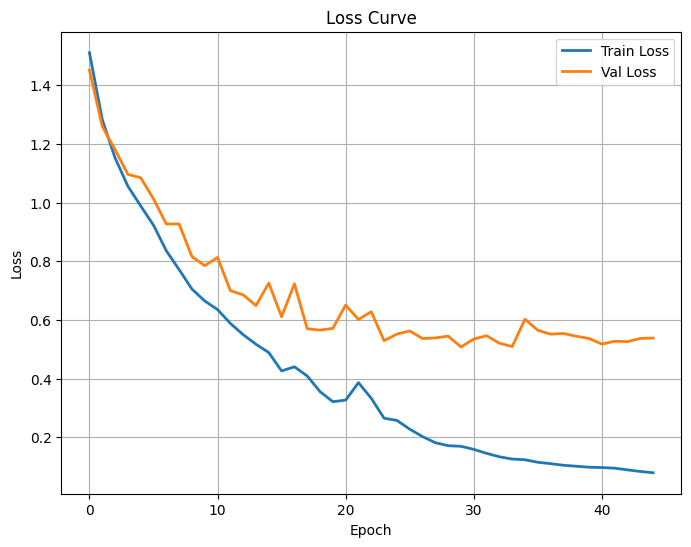

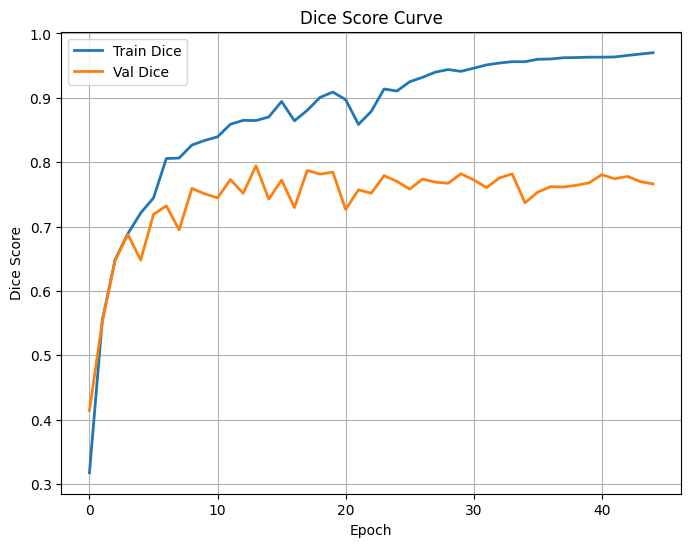

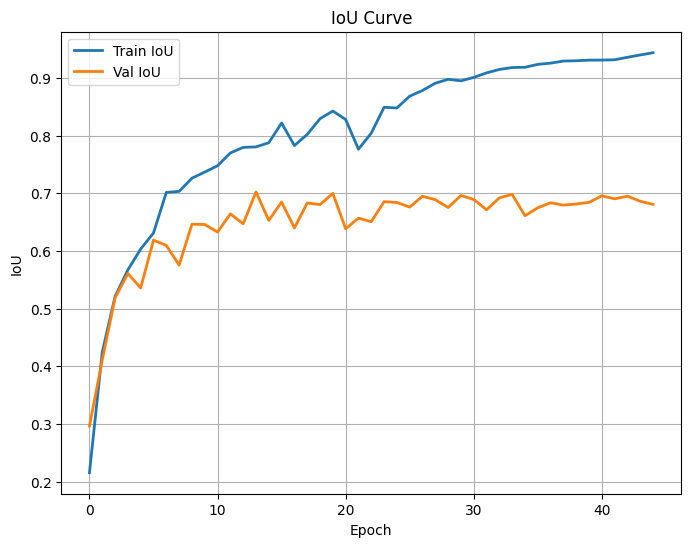

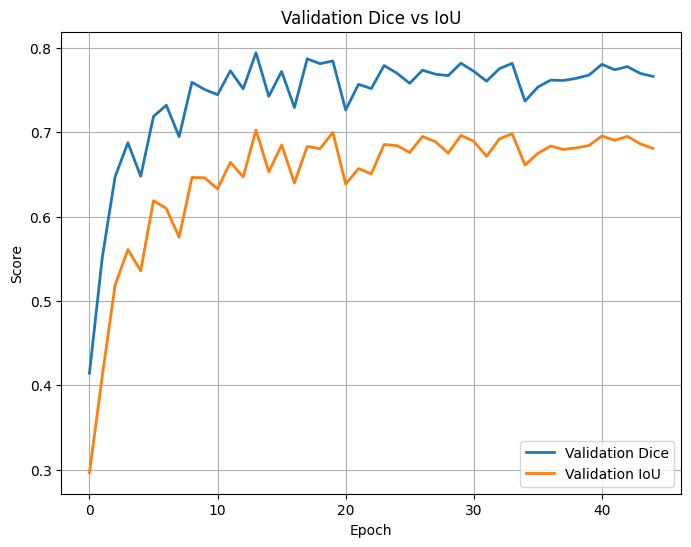

✅ All figures saved successfully!
📁 Location: /kaggle/working/UNet


In [12]:
import matplotlib.pyplot as plt
import os

# Save directory
save_dir = "/kaggle/working/UNet"
os.makedirs(save_dir, exist_ok=True)


plt.figure(figsize=(8, 6))
plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(val_losses, label="Val Loss", linewidth=2)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(save_dir, "loss_curve.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(save_dir, "loss_curve.pdf"),
            bbox_inches="tight")

plt.show()
plt.close()



plt.figure(figsize=(8, 6))
plt.plot(train_dices, label="Train Dice", linewidth=2)
plt.plot(val_dices, label="Val Dice", linewidth=2)
plt.title("Dice Score Curve")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(save_dir, "dice_curve.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(save_dir, "dice_curve.pdf"),
            bbox_inches="tight")

plt.show()
plt.close()



plt.figure(figsize=(8, 6))
plt.plot(train_ious, label="Train IoU", linewidth=2)
plt.plot(val_ious, label="Val IoU", linewidth=2)
plt.title("IoU Curve")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(save_dir, "iou_curve.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(save_dir, "iou_curve.pdf"),
            bbox_inches="tight")

plt.show()
plt.close()



plt.figure(figsize=(8, 6))
plt.plot(val_dices, label="Validation Dice", linewidth=2)
plt.plot(val_ious, label="Validation IoU", linewidth=2)
plt.title("Validation Dice vs IoU")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(save_dir, "validation_dice_vs_iou.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(save_dir, "validation_dice_vs_iou.pdf"),
            bbox_inches="tight")

plt.show()
plt.close()

print("✅ All figures saved successfully!")
print(f"📁 Location: {save_dir}")

In [13]:
import torch
import numpy as np
from scipy.ndimage import binary_erosion, distance_transform_edt


def get_boundary(mask):
    mask = mask.astype(bool)
    return mask ^ binary_erosion(mask) if mask.any() else np.zeros_like(mask, dtype=bool)


def boundary_f1(pred, gt, tolerance=2):
    pred_b, gt_b = get_boundary(pred), get_boundary(gt)
    if not pred_b.any() or not gt_b.any():
        return 0.0
    gt_dist, pred_dist = distance_transform_edt(~gt_b), distance_transform_edt(~pred_b)
    precision = np.mean(gt_dist[pred_b] <= tolerance)
    recall = np.mean(pred_dist[gt_b] <= tolerance)
    return float(2 * precision * recall / (precision + recall + 1e-6))


def surface_distances(pred, gt):
    pred, gt = pred.astype(bool), gt.astype(bool)
    if not pred.any() or not gt.any():
        return np.nan, np.nan
    pred_b, gt_b = get_boundary(pred), get_boundary(gt)
    if not pred_b.any() or not gt_b.any():
        return np.nan, np.nan
    gt_dist, pred_dist = distance_transform_edt(~gt_b), distance_transform_edt(~pred_b)
    d_pred_gt, d_gt_pred = gt_dist[pred_b], pred_dist[gt_b]
    assd = (d_pred_gt.sum() + d_gt_pred.sum()) / (len(d_pred_gt) + len(d_gt_pred))
    hd95 = max(np.percentile(d_pred_gt, 95), np.percentile(d_gt_pred, 95))
    return float(assd), float(hd95)


def evaluate_segmentation(model, test_loader, device, threshold=0.4):
    model.eval().to(device)
    dice_all, iou_all, bf1_all, assd_all, hd95_all = [[], []], [[], []], [[], []], [[], []], [[], []]
    TP, FP, FN = [0, 0], [0, 0], [0, 0]
    total_correct = total_pixels = 0

    with torch.inference_mode():
        for imgs, masks, labels in test_loader:
            imgs = imgs.to(device, dtype=torch.float32, non_blocking=True)
            masks = masks.cpu()


            main_logits, _ = model(imgs)
            preds = (torch.sigmoid(main_logits) > threshold).squeeze(1).cpu()

            total_correct += (preds == masks).sum().item()
            total_pixels += masks.numel()
            del imgs

            for b in range(preds.size(0)):
                pred = preds[b].numpy().astype(np.uint8)
                gt = masks[b].numpy().astype(np.uint8)
                for c in range(2):
                    p, g = pred == c, gt == c
                    inter = np.logical_and(p, g).sum()
                    p_sum, g_sum = p.sum(), g.sum()
                    union = p_sum + g_sum
                    dice_all[c].append((2 * inter + 1e-6) / (union + 1e-6))
                    iou_all[c].append((inter + 1e-6) / (union - inter + 1e-6))
                    TP[c] += int(np.logical_and(p, g).sum())
                    FP[c] += int(np.logical_and(p, ~g).sum())
                    FN[c] += int(np.logical_and(~p, g).sum())
                    bf1_all[c].append(boundary_f1(p, g, tolerance=2))
                    assd, hd95 = surface_distances(p, g)
                    if not np.isnan(assd):
                        assd_all[c].append(assd)
                        hd95_all[c].append(hd95)

            del preds, masks
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    precision, recall, f1 = [], [], []
    for c in range(2):
        p = TP[c] / (TP[c] + FP[c] + 1e-6)
        r = TP[c] / (TP[c] + FN[c] + 1e-6)
        precision.append(p)
        recall.append(r)
        f1.append(2 * p * r / (p + r + 1e-6))

    def mean(x):
        return float(np.mean(x)) if x else 0.0

    def std(x):
        return float(np.std(x, ddof=1)) if len(x) > 1 else 0.0

    names = ["Background", "Polyp"]
    print("\n==================== Test Set Metrics ====================")
    print(f"Overall Pixel Accuracy : {total_correct / (total_pixels + 1e-6):.4f}")
    print("----------------------------------------------------------")
    print(f"{'Class':<15}{'Dice':>8}{'IoU':>8}{'BF1':>8}{'ASSD':>9}{'HD95':>9}{'F1':>8}")
    print("----------------------------------------------------------")

    metrics = {}
    for c in range(2):
        d, i, b, a, h = map(mean, [dice_all[c], iou_all[c], bf1_all[c], assd_all[c], hd95_all[c]])
        metrics[c] = {"dice": d, "iou": i, "bf1": b, "assd": a, "hd95": h}
        print(f"{names[c]:<15}{d:8.4f}{i:8.4f}{b:8.4f}{a:9.2f}{h:9.2f}{f1[c]:8.4f}")

    mean_dice = np.mean([metrics[0]["dice"], metrics[1]["dice"]])
    mean_iou = np.mean([metrics[0]["iou"], metrics[1]["iou"]])
    mean_bf1 = np.mean([metrics[0]["bf1"], metrics[1]["bf1"]])
    mean_assd = np.mean([metrics[0]["assd"], metrics[1]["assd"]])
    mean_hd95 = np.mean([metrics[0]["hd95"], metrics[1]["hd95"]])
    mean_f1 = np.mean(f1)

    print("----------------------------------------------------------")
    print(f"{'Mean':<15}{mean_dice:8.4f}{mean_iou:8.4f}{mean_bf1:8.4f}{mean_assd:9.2f}{mean_hd95:9.2f}{mean_f1:8.4f}")
    print("==========================================================")

    accuracy = total_correct / (total_pixels + 1e-6)
    print("\n── Polyp Class (Primary Metrics) ──")
    print(f"Dice       : {metrics[1]['dice']:.4f}")
    print(f"IoU        : {metrics[1]['iou']:.4f}")
    print(f"Boundary F1: {metrics[1]['bf1']:.4f}")
    print(f"ASSD       : {metrics[1]['assd']:.2f}")
    print(f"HD95       : {metrics[1]['hd95']:.2f}")
    print(f"Precision  : {precision[1]:.4f}")
    print(f"Recall     : {recall[1]:.4f}")
    print(f"F1         : {f1[1]:.4f}")
    print("==========================================================\n")

    return {
        "accuracy": accuracy,
        "mean_dice": mean_dice,
        "mean_iou": mean_iou,
        "mean_boundary_f1": mean_bf1,
        "mean_assd": mean_assd,
        "mean_hd95": mean_hd95,
        "mean_f1": mean_f1,
        "polyp_dice": metrics[1]["dice"],
        "polyp_iou": metrics[1]["iou"],
        "polyp_boundary_f1": metrics[1]["bf1"],
        "polyp_assd": metrics[1]["assd"],
        "polyp_hd95": metrics[1]["hd95"],
        "polyp_precision": precision[1],
        "polyp_recall": recall[1],
        "polyp_f1": f1[1]
    }


results = evaluate_segmentation(model, test_loader, device=device, threshold=0.4)


==================== Test Set Metrics ====================
Overall Pixel Accuracy : 0.9544
----------------------------------------------------------
Class              Dice     IoU     BF1     ASSD     HD95      F1
----------------------------------------------------------
Background       0.9722  0.9497  0.8932     1.84    15.51  0.9749
Polyp            0.7521  0.6713  0.5039    10.20    27.04  0.7539
----------------------------------------------------------
Mean             0.8622  0.8105  0.6985     6.02    21.28  0.8644

── Polyp Class (Primary Metrics) ──
Dice       : 0.7521
IoU        : 0.6713
Boundary F1: 0.5039
ASSD       : 10.20
HD95       : 27.04
Precision  : 0.7520
Recall     : 0.7558
F1         : 0.7539



Image:
/kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png

Ground Truth Mask:
/kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks/benign (1)_mask.png


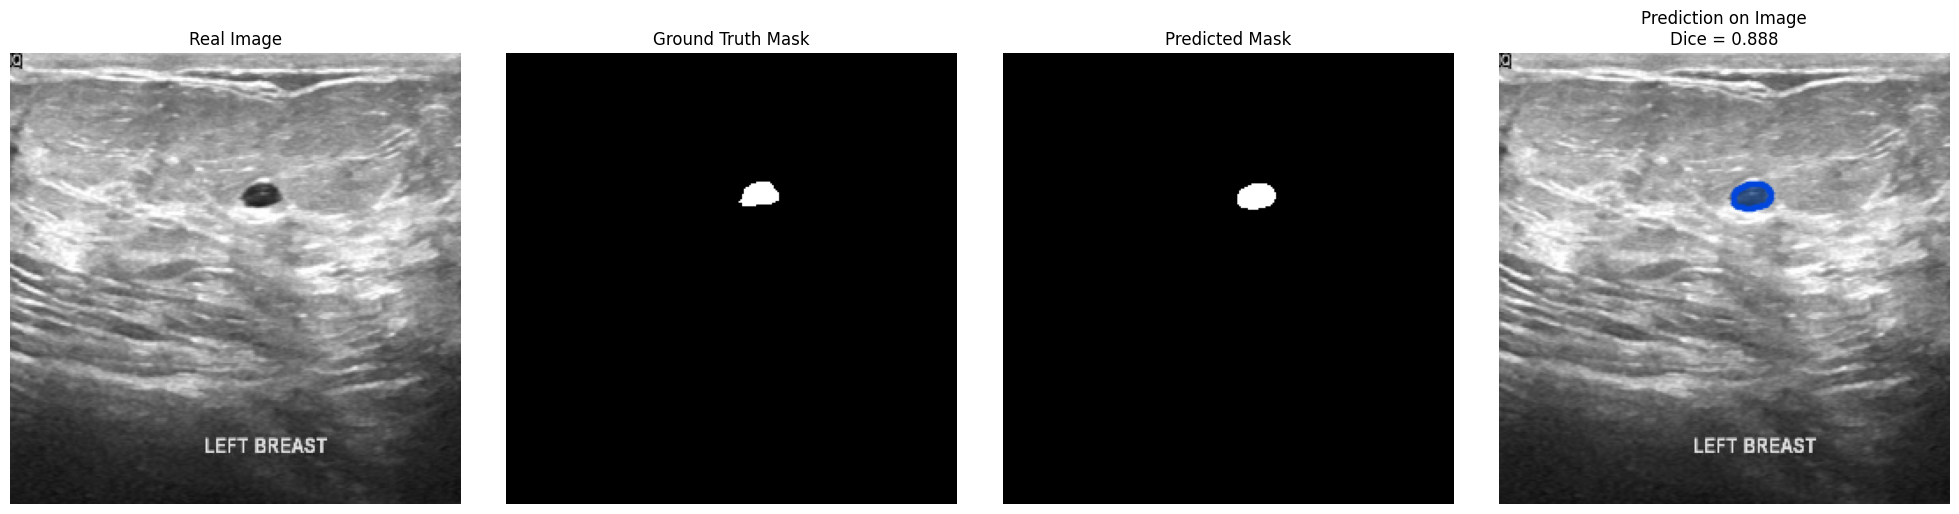


Visualization completed!
Image       : /kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png
GT Mask     : /kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks/benign (1)_mask.png
Dice        : 0.8884

Saved files:
/kaggle/working/UNet/XAI/real_image.png
/kaggle/working/UNet/XAI/ground_truth_mask.png
/kaggle/working/UNet/XAI/predicted_mask.png
/kaggle/working/UNet/XAI/predicted_mask_on_image.png


In [14]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


IMAGE_PATH = "/kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png"

MASK_DIR = "/kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks"

SAVE_DIR = "/kaggle/working/UNet/XAI"
os.makedirs(SAVE_DIR, exist_ok=True)


THRESHOLD = 0.4

MASK_COLOR = np.array(
    [30, 120, 255],
    dtype=np.uint8
)

BORDER_COLOR = (0, 70, 220)

MASK_ALPHA = 0.35
BORDER_WIDTH = 2


image_filename = os.path.basename(IMAGE_PATH)

base_name = os.path.splitext(
    image_filename
)[0]

mask_path = os.path.join(
    MASK_DIR,
    base_name + "_mask.png"
)

if not os.path.exists(mask_path):

    found_mask = None

    for ext in [
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp"
    ]:

        temp_path = os.path.join(
            MASK_DIR,
            base_name + "_mask" + ext
        )

        if os.path.exists(temp_path):
            found_mask = temp_path
            break

    if found_mask is None:
        raise FileNotFoundError(
            f"Mask not found for:\n{IMAGE_PATH}\n\n"
            f"Expected mask similar to:\n"
            f"{base_name}_mask.png"
        )

    mask_path = found_mask


print("Image:")
print(IMAGE_PATH)

print("\nGround Truth Mask:")
print(mask_path)


original_pil = Image.open(
    IMAGE_PATH
).convert("RGB")

original_image = np.array(
    original_pil
)


gt_pil = Image.open(
    mask_path
).convert("L")

gt_mask_original = np.array(
    gt_pil
)

gt_mask_original = (
    gt_mask_original > 127
).astype(np.uint8)


model_input = image_transform(
    original_pil
)

model_input = model_input.unsqueeze(
    0
).to(device)


model.eval()

with torch.no_grad():

    output = model(
        model_input
    )

    if isinstance(
        output,
        (tuple, list)
    ):
        output = output[0]

    probability = torch.sigmoid(
        output
    )

    predicted_mask = (
        probability > THRESHOLD
    ).long()


predicted_mask = (
    predicted_mask
    .squeeze()
    .cpu()
    .numpy()
    .astype(np.uint8)
)


output_h, output_w = predicted_mask.shape


gt_mask = cv2.resize(
    gt_mask_original,
    (output_w, output_h),
    interpolation=cv2.INTER_NEAREST
)

gt_mask = (
    gt_mask > 0
).astype(np.uint8)


display_image = cv2.resize(
    original_image,
    (output_w, output_h),
    interpolation=cv2.INTER_LINEAR
)

display_image = np.ascontiguousarray(
    display_image,
    dtype=np.uint8
)


gt_mask_display = (
    gt_mask * 255
).astype(np.uint8)


pred_mask_display = (
    predicted_mask * 255
).astype(np.uint8)


overlay = display_image.copy()

prediction_pixels = (
    predicted_mask == 1
)

overlay[prediction_pixels] = (
    overlay[prediction_pixels].astype(
        np.float32
    )
    * (1 - MASK_ALPHA)
    +
    MASK_COLOR.astype(
        np.float32
    )
    * MASK_ALPHA
).astype(np.uint8)


contours, _ = cv2.findContours(
    predicted_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

overlay = np.ascontiguousarray(
    overlay
)

cv2.drawContours(
    overlay,
    contours,
    -1,
    BORDER_COLOR,
    BORDER_WIDTH,
    lineType=cv2.LINE_AA
)


intersection = np.logical_and(
    predicted_mask == 1,
    gt_mask == 1
).sum()

pred_area = (
    predicted_mask == 1
).sum()

gt_area = (
    gt_mask == 1
).sum()

dice = (
    2.0 * intersection
    /
    (pred_area + gt_area + 1e-8)
)


save_path = os.path.join(
    SAVE_DIR,
    "real_image.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(
    display_image
)

plt.title(
    "Real Image",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


save_path = os.path.join(
    SAVE_DIR,
    "ground_truth_mask.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(
    gt_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title(
    "Ground Truth Mask",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


save_path = os.path.join(
    SAVE_DIR,
    "predicted_mask.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(
    pred_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title(
    "Predicted Mask",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


save_path = os.path.join(
    SAVE_DIR,
    "predicted_mask_on_image.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(
    overlay
)

plt.title(
    f"Predicted Mask on Image\nDice = {dice:.3f}",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()


fig, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5)
)

axes[0].imshow(
    display_image
)

axes[0].set_title(
    "Real Image"
)

axes[1].imshow(
    gt_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)

axes[1].set_title(
    "Ground Truth Mask"
)

axes[2].imshow(
    pred_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)

axes[2].set_title(
    "Predicted Mask"
)

axes[3].imshow(
    overlay
)

axes[3].set_title(
    f"Prediction on Image\nDice = {dice:.3f}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

plt.close()


print("\n" + "=" * 60)
print("Visualization completed!")
print("=" * 60)

print(
    f"Image       : {IMAGE_PATH}"
)

print(
    f"GT Mask     : {mask_path}"
)

print(
    f"Dice        : {dice:.4f}"
)

print("\nSaved files:")

print(
    os.path.join(
        SAVE_DIR,
        "real_image.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "ground_truth_mask.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "predicted_mask.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "predicted_mask_on_image.png"
    )
)

print("=" * 60)

# Attention-UNet + ResNet34 + RFB

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm


class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1, d=1):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_ch,
                out_ch,
                k,
                s,
                p,
                dilation=d,
                bias=False
            ),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class RFB(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        inter = out_ch // 4

        self.branch0 = nn.Sequential(
            ConvBNReLU(
                in_ch,
                inter,
                k=1,
                p=0
            ),
        )

        self.branch1 = nn.Sequential(
            ConvBNReLU(
                in_ch,
                inter,
                k=1,
                p=0
            ),
            ConvBNReLU(
                inter,
                inter,
                k=3,
                p=1,
                d=1
            ),
        )

        self.branch2 = nn.Sequential(
            ConvBNReLU(
                in_ch,
                inter,
                k=1,
                p=0
            ),
            ConvBNReLU(
                inter,
                inter,
                k=3,
                p=3,
                d=3
            ),
        )

        self.branch3 = nn.Sequential(
            ConvBNReLU(
                in_ch,
                inter,
                k=1,
                p=0
            ),
            ConvBNReLU(
                inter,
                inter,
                k=3,
                p=5,
                d=5
            ),
        )

        self.fuse = ConvBNReLU(
            inter * 4,
            out_ch,
            k=1,
            p=0
        )

        self.shortcut = nn.Sequential(
            nn.Conv2d(
                in_ch,
                out_ch,
                1,
                bias=False
            ),
            nn.BatchNorm2d(out_ch),
        )

        self.relu = nn.ReLU(
            inplace=True
        )

    def forward(self, x):
        b0 = self.branch0(x)
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)

        out = self.fuse(
            torch.cat(
                [
                    b0,
                    b1,
                    b2,
                    b3
                ],
                dim=1
            )
        )

        out = out + self.shortcut(x)

        return self.relu(out)


class AttentionGate(nn.Module):
    def __init__(self, g_ch, x_ch, inter_ch):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(
                g_ch,
                inter_ch,
                1,
                bias=True
            ),
            nn.BatchNorm2d(
                inter_ch
            ),
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(
                x_ch,
                inter_ch,
                1,
                bias=True
            ),
            nn.BatchNorm2d(
                inter_ch
            ),
        )

        self.psi = nn.Sequential(
            nn.Conv2d(
                inter_ch,
                1,
                1,
                bias=True
            ),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )

        self.relu = nn.ReLU(
            inplace=True
        )

    def forward(self, g, x):
        if g.shape[2:] != x.shape[2:]:
            g = F.interpolate(
                g,
                size=x.shape[2:],
                mode="bilinear",
                align_corners=False
            )

        psi = self.relu(
            self.W_g(g) + self.W_x(x)
        )

        psi = self.psi(psi)

        return x * psi


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()

        self.att = AttentionGate(
            g_ch=in_ch,
            x_ch=skip_ch,
            inter_ch=skip_ch // 2
        )

        self.conv = nn.Sequential(
            ConvBNReLU(
                in_ch + skip_ch,
                out_ch
            ),
            ConvBNReLU(
                out_ch,
                out_ch
            ),
        )

    def forward(self, x, skip):
        x_up = F.interpolate(
            x,
            size=skip.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        skip_gated = self.att(
            g=x,
            x=skip
        )

        x_cat = torch.cat(
            [
                x_up,
                skip_gated
            ],
            dim=1
        )

        return self.conv(x_cat)


class AttentionUNetRFB(nn.Module):
    def __init__(
        self,
        out_channels=1,
        pretrained=True,
        decoder_channels=(256, 128, 64, 32)
    ):
        super().__init__()

        resnet = tvm.resnet34(
            weights=(
                tvm.ResNet34_Weights.IMAGENET1K_V1
                if pretrained
                else None
            )
        )

        self.stem = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu
        )

        self.pool = resnet.maxpool

        self.enc1 = resnet.layer1
        self.enc2 = resnet.layer2
        self.enc3 = resnet.layer3
        self.enc4 = resnet.layer4

        self.rfb = RFB(
            512,
            512
        )

        c0, c1, c2, c3 = decoder_channels

        self.dec4 = DecoderBlock(
            in_ch=512,
            skip_ch=256,
            out_ch=c0
        )

        self.dec3 = DecoderBlock(
            in_ch=c0,
            skip_ch=128,
            out_ch=c1
        )

        self.dec2 = DecoderBlock(
            in_ch=c1,
            skip_ch=64,
            out_ch=c2
        )

        self.dec1 = DecoderBlock(
            in_ch=c2,
            skip_ch=64,
            out_ch=c3
        )

        self.final_up = nn.Sequential(
            ConvBNReLU(
                c3,
                c3
            ),
            nn.Upsample(
                scale_factor=2,
                mode="bilinear",
                align_corners=False
            ),
            ConvBNReLU(
                c3,
                c3
            ),
        )

        self.head_main = nn.Conv2d(
            c3,
            out_channels,
            1
        )

        self.head_aux3 = nn.Conv2d(
            c1,
            out_channels,
            1
        )

        self.head_aux2 = nn.Conv2d(
            c2,
            out_channels,
            1
        )

    def forward(self, x):
        H, W = x.shape[2:]

        s0 = self.stem(x)
        s0p = self.pool(s0)

        e1 = self.enc1(s0p)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)

        bottleneck = self.rfb(e4)

        d4 = self.dec4(
            bottleneck,
            e3
        )

        d3 = self.dec3(
            d4,
            e2
        )

        d2 = self.dec2(
            d3,
            e1
        )

        d1 = self.dec1(
            d2,
            s0
        )

        out = self.final_up(d1)

        main_logits = self.head_main(
            out
        )

        aux3_logits = self.head_aux3(
            d3
        )

        aux2_logits = self.head_aux2(
            d2
        )

        main_logits = F.interpolate(
            main_logits,
            size=(H, W),
            mode="bilinear",
            align_corners=False
        )

        aux3_logits = F.interpolate(
            aux3_logits,
            size=(H, W),
            mode="bilinear",
            align_corners=False
        )

        aux2_logits = F.interpolate(
            aux2_logits,
            size=(H, W),
            mode="bilinear",
            align_corners=False
        )

        return main_logits, [
            aux3_logits,
            aux2_logits
        ]


if __name__ == "__main__":

    model = AttentionUNetRFB(
        out_channels=1,
        pretrained=True
    )

    x = torch.randn(
        2,
        3,
        352,
        352
    )

    main_out, aux_outs = model(x)

    print(
        "main:",
        main_out.shape
    )

    for i, a in enumerate(aux_outs):
        print(
            f"aux{i}:",
            a.shape
        )

    n_params = sum(
        p.numel()
        for p in model.parameters()
    ) / 1e6

    print(
        f"Params: {n_params:.2f}M"
    )

main: torch.Size([2, 1, 352, 352])
aux0: torch.Size([2, 1, 352, 352])
aux1: torch.Size([2, 1, 352, 352])
Params: 25.82M


In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


class CombinedLoss(nn.Module):
    def __init__(self, dice_weight=0.7, bce_weight=0.3):
        super().__init__()
        self.dice = DiceLoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.dw = dice_weight
        self.bw = bce_weight

    def forward(self, logits, targets):
        if targets.dim() == 3:
            targets = targets.unsqueeze(1)
        targets = targets.float()
        return self.dw * self.dice(logits, targets) + \
               self.bw * self.bce(logits, targets)


def dice_score(logits, targets, smooth=1e-6, thresh=0.4):
    probs = torch.sigmoid(logits)
    preds = (probs > thresh).float()
    if targets.dim() == 3:
        targets = targets.unsqueeze(1)
    targets = targets.float()
    intersection = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
    dice = (2 * intersection + smooth) / (union + smooth)
    return dice.mean()


def iou_score(logits, targets, smooth=1e-6, thresh=0.4):
    probs = torch.sigmoid(logits)
    preds = (probs > thresh).float()
    if targets.dim() == 3:
        targets = targets.unsqueeze(1)
    targets = targets.float()
    intersection = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou.mean()


def deep_supervision_loss(criterion, main_logits, aux_logits_list, masks, aux_weight=0.4):
    loss = criterion(main_logits, masks)
    for aux in aux_logits_list:
        loss = loss + aux_weight * criterion(aux, masks)
    return loss


class EarlyStopping:
    def __init__(self, patience=15, verbose=True):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), "best_model.pth")
            if self.verbose:
                print(f"  Val loss improved to {val_loss:.4f} — model saved.")
        else:
            self.counter += 1
            if self.verbose:
                print(f"  No improvement: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                print("  Early stopping triggered.")
                self.stop = True


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

criterion = CombinedLoss().to(device)

num_epochs = 200
aux_weight = 0.6

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-6
)

early_stopping = EarlyStopping(patience=15, verbose=True)


train_losses, val_losses = [], []
train_dices, val_dices = [], []
train_ious, val_ious = [], []


for epoch in range(num_epochs):

    model.train()
    train_loss = 0.0
    train_dice = 0.0
    train_iou = 0.0

    for imgs, masks, labels in train_loader:
        imgs = imgs.to(device, dtype=torch.float32)
        masks = masks.to(device, dtype=torch.float32)

        optimizer.zero_grad(set_to_none=True)

        main_logits, aux_logits = model(imgs)

        loss = deep_supervision_loss(criterion, main_logits, aux_logits, masks, aux_weight)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_dice += dice_score(main_logits, masks).item()
        train_iou += iou_score(main_logits, masks).item()


    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    val_iou = 0.0

    with torch.no_grad():
        for imgs, masks, labels in val_loader:
            imgs = imgs.to(device, dtype=torch.float32)
            masks = masks.to(device, dtype=torch.float32)

            main_logits, aux_logits = model(imgs)

            loss = deep_supervision_loss(criterion, main_logits, aux_logits, masks, aux_weight)

            val_loss += loss.item()
            val_dice += dice_score(main_logits, masks).item()
            val_iou += iou_score(main_logits, masks).item()


    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_train_dice = train_dice / len(train_loader)
    avg_val_dice = val_dice / len(val_loader)
    avg_train_iou = train_iou / len(train_loader)
    avg_val_iou = val_iou / len(val_loader)


    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_dices.append(avg_train_dice)
    val_dices.append(avg_val_dice)
    train_ious.append(avg_train_iou)
    val_ious.append(avg_val_iou)


    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Dice: {avg_val_dice:.4f} | "
        f"IoU: {avg_val_iou:.4f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.2e}"
    )


    scheduler.step()


    early_stopping(avg_val_loss, model)
    if early_stopping.stop:
        print(f"\nTraining stopped early at epoch {epoch+1}.")
        break


model.load_state_dict(torch.load("best_model.pth", map_location=device))
model = model.to(device)
print("\nBest model loaded for evaluation.")

Epoch [1/200] Train Loss: 0.1311 | Val Loss: 0.4697 | Dice: 0.7938 | IoU: 0.7009 | LR: 3.00e-04
  Val loss improved to 0.4697 — model saved.
Epoch [2/200] Train Loss: 0.1400 | Val Loss: 0.4417 | Dice: 0.7988 | IoU: 0.7092 | LR: 3.00e-04
  Val loss improved to 0.4417 — model saved.
Epoch [3/200] Train Loss: 0.1898 | Val Loss: 0.5678 | Dice: 0.7540 | IoU: 0.6693 | LR: 3.00e-04
  No improvement: 1/15
Epoch [6/200] Train Loss: 0.1505 | Val Loss: 0.5583 | Dice: 0.7626 | IoU: 0.6685 | LR: 3.00e-04
  No improvement: 4/15
Epoch [7/200] Train Loss: 0.1390 | Val Loss: 0.5131 | Dice: 0.7653 | IoU: 0.6830 | LR: 2.99e-04
  No improvement: 5/15
Epoch [8/200] Train Loss: 0.1147 | Val Loss: 0.4903 | Dice: 0.7787 | IoU: 0.6931 | LR: 2.99e-04
  No improvement: 6/15
Epoch [9/200] Train Loss: 0.0967 | Val Loss: 0.4665 | Dice: 0.7917 | IoU: 0.7028 | LR: 2.99e-04
  No improvement: 7/15
Epoch [10/200] Train Loss: 0.1007 | Val Loss: 0.5415 | Dice: 0.7673 | IoU: 0.6758 | LR: 2.99e-04
  No improvement: 8/15
Epo

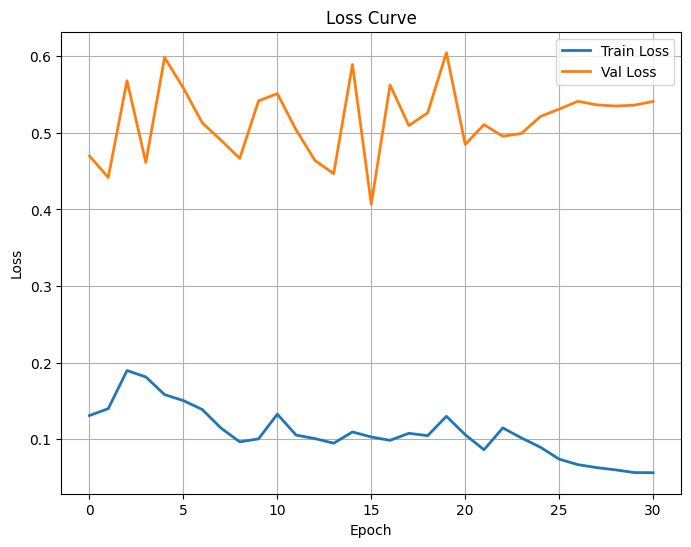

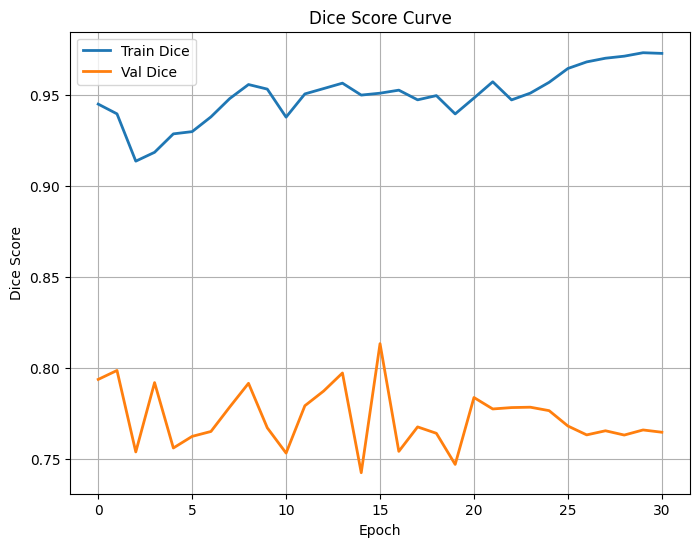

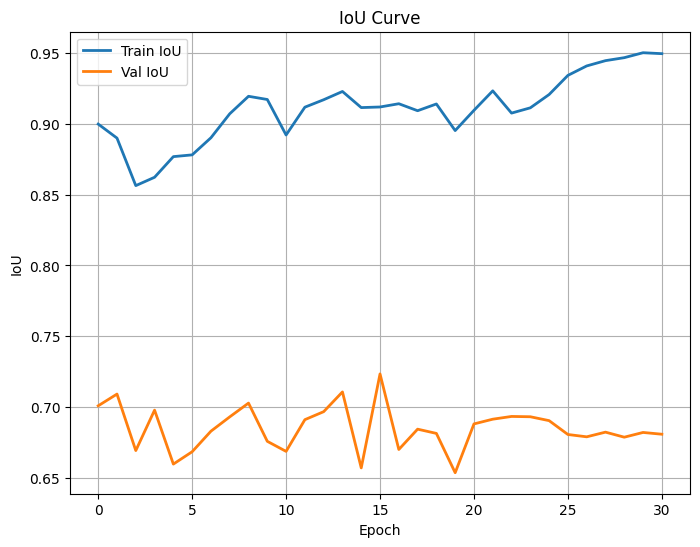

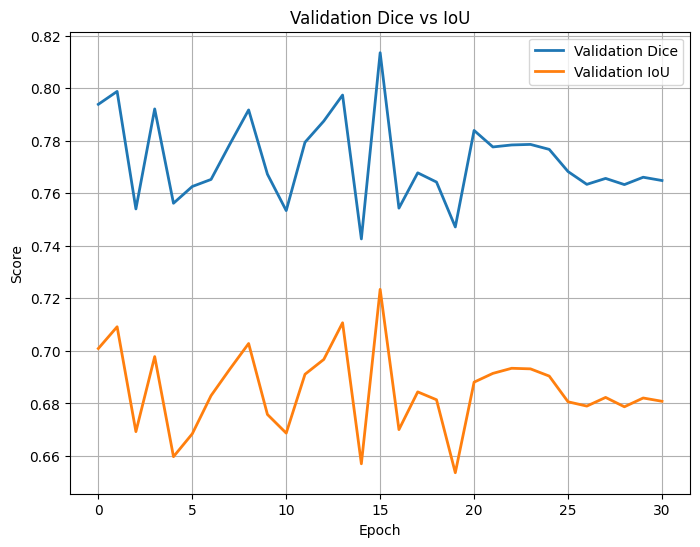

✅ All figures saved successfully!
📁 Location: /kaggle/working/UNet


In [18]:
import matplotlib.pyplot as plt
import os

save_dir = "/kaggle/working/UNet"
os.makedirs(save_dir, exist_ok=True)


plt.figure(figsize=(8, 6))
plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(val_losses, label="Val Loss", linewidth=2)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(save_dir, "loss_curve.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(save_dir, "loss_curve.pdf"),
            bbox_inches="tight")

plt.show()
plt.close()


plt.figure(figsize=(8, 6))
plt.plot(train_dices, label="Train Dice", linewidth=2)
plt.plot(val_dices, label="Val Dice", linewidth=2)
plt.title("Dice Score Curve")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(save_dir, "dice_curve.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(save_dir, "dice_curve.pdf"),
            bbox_inches="tight")

plt.show()
plt.close()


plt.figure(figsize=(8, 6))
plt.plot(train_ious, label="Train IoU", linewidth=2)
plt.plot(val_ious, label="Val IoU", linewidth=2)
plt.title("IoU Curve")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(save_dir, "iou_curve.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(save_dir, "iou_curve.pdf"),
            bbox_inches="tight")

plt.show()
plt.close()


plt.figure(figsize=(8, 6))
plt.plot(val_dices, label="Validation Dice", linewidth=2)
plt.plot(val_ious, label="Validation IoU", linewidth=2)
plt.title("Validation Dice vs IoU")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(save_dir, "validation_dice_vs_iou.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(save_dir, "validation_dice_vs_iou.pdf"),
            bbox_inches="tight")

plt.show()
plt.close()

print("✅ All figures saved successfully!")
print(f"📁 Location: {save_dir}")

In [19]:
import torch
import numpy as np
from scipy.ndimage import binary_erosion, distance_transform_edt


def get_boundary(mask):
    mask = mask.astype(bool)
    return mask ^ binary_erosion(mask) if mask.any() else np.zeros_like(mask, dtype=bool)


def boundary_f1(pred, gt, tolerance=2):
    pred_b, gt_b = get_boundary(pred), get_boundary(gt)
    if not pred_b.any() or not gt_b.any():
        return 0.0
    gt_dist, pred_dist = distance_transform_edt(~gt_b), distance_transform_edt(~pred_b)
    precision = np.mean(gt_dist[pred_b] <= tolerance)
    recall = np.mean(pred_dist[gt_b] <= tolerance)
    return float(2 * precision * recall / (precision + recall + 1e-6))


def surface_distances(pred, gt):
    pred, gt = pred.astype(bool), gt.astype(bool)
    if not pred.any() or not gt.any():
        return np.nan, np.nan
    pred_b, gt_b = get_boundary(pred), get_boundary(gt)
    if not pred_b.any() or not gt_b.any():
        return np.nan, np.nan
    gt_dist, pred_dist = distance_transform_edt(~gt_b), distance_transform_edt(~pred_b)
    d_pred_gt, d_gt_pred = gt_dist[pred_b], pred_dist[gt_b]
    assd = (d_pred_gt.sum() + d_gt_pred.sum()) / (len(d_pred_gt) + len(d_gt_pred))
    hd95 = max(np.percentile(d_pred_gt, 95), np.percentile(d_gt_pred, 95))
    return float(assd), float(hd95)


def evaluate_segmentation(model, test_loader, device, threshold=0.4):
    model.eval().to(device)
    dice_all, iou_all, bf1_all, assd_all, hd95_all = [[], []], [[], []], [[], []], [[], []], [[], []]
    TP, FP, FN = [0, 0], [0, 0], [0, 0]
    total_correct = total_pixels = 0

    with torch.inference_mode():
        for imgs, masks, labels in test_loader:
            imgs = imgs.to(device, dtype=torch.float32, non_blocking=True)
            masks = masks.cpu()

            main_logits, _ = model(imgs)
            preds = (torch.sigmoid(main_logits) > threshold).squeeze(1).cpu()

            total_correct += (preds == masks).sum().item()
            total_pixels += masks.numel()
            del imgs

            for b in range(preds.size(0)):
                pred = preds[b].numpy().astype(np.uint8)
                gt = masks[b].numpy().astype(np.uint8)
                for c in range(2):
                    p, g = pred == c, gt == c
                    inter = np.logical_and(p, g).sum()
                    p_sum, g_sum = p.sum(), g.sum()
                    union = p_sum + g_sum
                    dice_all[c].append((2 * inter + 1e-6) / (union + 1e-6))
                    iou_all[c].append((inter + 1e-6) / (union - inter + 1e-6))
                    TP[c] += int(np.logical_and(p, g).sum())
                    FP[c] += int(np.logical_and(p, ~g).sum())
                    FN[c] += int(np.logical_and(~p, g).sum())
                    bf1_all[c].append(boundary_f1(p, g, tolerance=2))
                    assd, hd95 = surface_distances(p, g)
                    if not np.isnan(assd):
                        assd_all[c].append(assd)
                        hd95_all[c].append(hd95)

            del preds, masks
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    precision, recall, f1 = [], [], []
    for c in range(2):
        p = TP[c] / (TP[c] + FP[c] + 1e-6)
        r = TP[c] / (TP[c] + FN[c] + 1e-6)
        precision.append(p)
        recall.append(r)
        f1.append(2 * p * r / (p + r + 1e-6))

    def mean(x):
        return float(np.mean(x)) if x else 0.0

    def std(x):
        return float(np.std(x, ddof=1)) if len(x) > 1 else 0.0

    names = ["Background", "Polyp"]
    print("\n==================== Test Set Metrics ====================")
    print(f"Overall Pixel Accuracy : {total_correct / (total_pixels + 1e-6):.4f}")
    print("----------------------------------------------------------")
    print(f"{'Class':<15}{'Dice':>8}{'IoU':>8}{'BF1':>8}{'ASSD':>9}{'HD95':>9}{'F1':>8}")
    print("----------------------------------------------------------")

    metrics = {}
    for c in range(2):
        d, i, b, a, h = map(mean, [dice_all[c], iou_all[c], bf1_all[c], assd_all[c], hd95_all[c]])
        metrics[c] = {"dice": d, "iou": i, "bf1": b, "assd": a, "hd95": h}
        print(f"{names[c]:<15}{d:8.4f}{i:8.4f}{b:8.4f}{a:9.2f}{h:9.2f}{f1[c]:8.4f}")

    mean_dice = np.mean([metrics[0]["dice"], metrics[1]["dice"]])
    mean_iou = np.mean([metrics[0]["iou"], metrics[1]["iou"]])
    mean_bf1 = np.mean([metrics[0]["bf1"], metrics[1]["bf1"]])
    mean_assd = np.mean([metrics[0]["assd"], metrics[1]["assd"]])
    mean_hd95 = np.mean([metrics[0]["hd95"], metrics[1]["hd95"]])
    mean_f1 = np.mean(f1)

    print("----------------------------------------------------------")
    print(f"{'Mean':<15}{mean_dice:8.4f}{mean_iou:8.4f}{mean_bf1:8.4f}{mean_assd:9.2f}{mean_hd95:9.2f}{mean_f1:8.4f}")
    print("==========================================================")

    accuracy = total_correct / (total_pixels + 1e-6)
    print("\n── Polyp Class (Primary Metrics) ──")
    print(f"Dice       : {metrics[1]['dice']:.4f}")
    print(f"IoU        : {metrics[1]['iou']:.4f}")
    print(f"Boundary F1: {metrics[1]['bf1']:.4f}")
    print(f"ASSD       : {metrics[1]['assd']:.2f}")
    print(f"HD95       : {metrics[1]['hd95']:.2f}")
    print(f"Precision  : {precision[1]:.4f}")
    print(f"Recall     : {recall[1]:.4f}")
    print(f"F1         : {f1[1]:.4f}")
    print("==========================================================\n")

    return {
        "accuracy": accuracy,
        "mean_dice": mean_dice,
        "mean_iou": mean_iou,
        "mean_boundary_f1": mean_bf1,
        "mean_assd": mean_assd,
        "mean_hd95": mean_hd95,
        "mean_f1": mean_f1,
        "polyp_dice": metrics[1]["dice"],
        "polyp_iou": metrics[1]["iou"],
        "polyp_boundary_f1": metrics[1]["bf1"],
        "polyp_assd": metrics[1]["assd"],
        "polyp_hd95": metrics[1]["hd95"],
        "polyp_precision": precision[1],
        "polyp_recall": recall[1],
        "polyp_f1": f1[1]
    }


results = evaluate_segmentation(model, test_loader, device=device, threshold=0.4)


==================== Test Set Metrics ====================
Overall Pixel Accuracy : 0.9462
----------------------------------------------------------
Class              Dice     IoU     BF1     ASSD     HD95      F1
----------------------------------------------------------
Background       0.9680  0.9427  0.8832     2.23    18.77  0.9706
Polyp            0.7005  0.6206  0.4516    13.50    31.45  0.6858
----------------------------------------------------------
Mean             0.8343  0.7816  0.6674     7.86    25.11  0.8282

── Polyp Class (Primary Metrics) ──
Dice       : 0.7005
IoU        : 0.6206
Boundary F1: 0.4516
ASSD       : 13.50
HD95       : 31.45
Precision  : 0.7448
Recall     : 0.6355
F1         : 0.6858



Image:
/kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png

Ground Truth Mask:
/kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks/benign (1)_mask.png


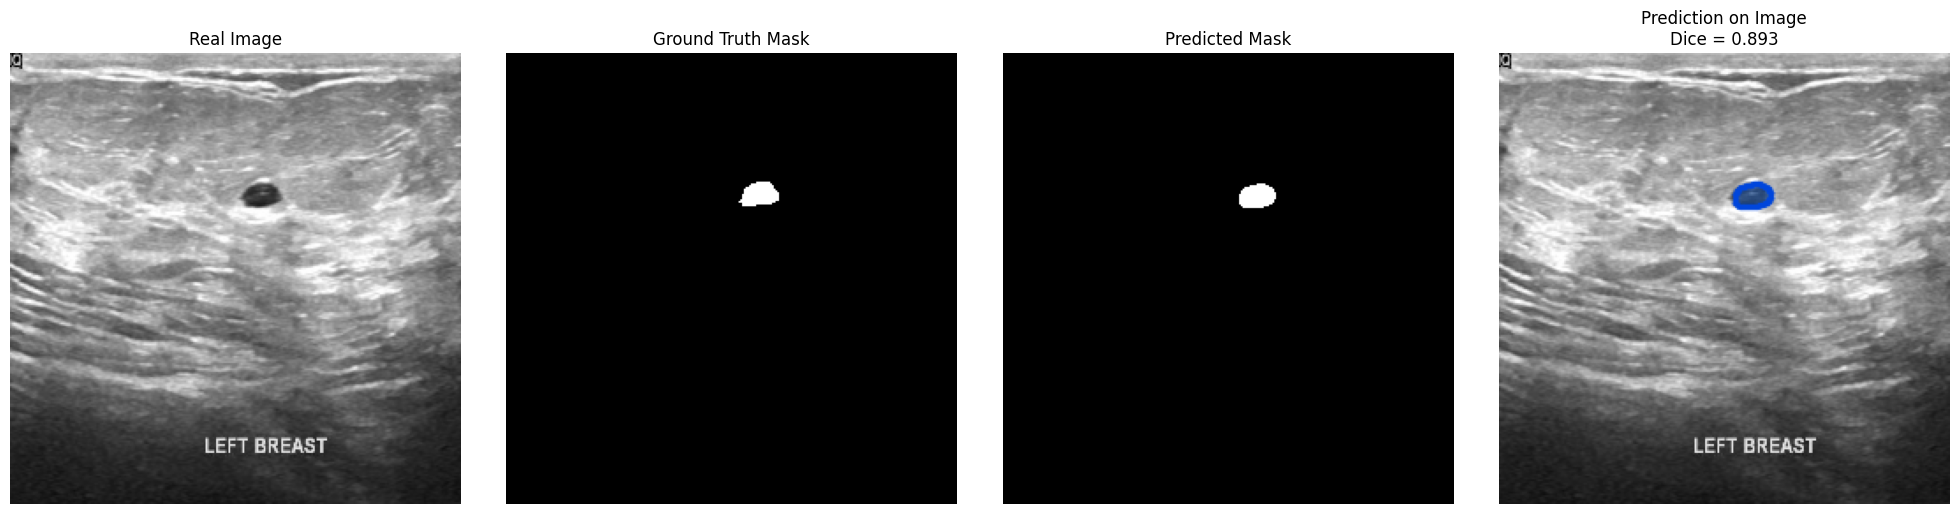


Visualization completed!
Image       : /kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png
GT Mask     : /kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks/benign (1)_mask.png
Dice        : 0.8931

Saved files:
/kaggle/working/UNet/XAI/real_image.png
/kaggle/working/UNet/XAI/ground_truth_mask.png
/kaggle/working/UNet/XAI/predicted_mask.png
/kaggle/working/UNet/XAI/predicted_mask_on_image.png


In [20]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

IMAGE_PATH = "/kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png"

MASK_DIR = "/kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks"

SAVE_DIR = "/kaggle/working/UNet/XAI"
os.makedirs(SAVE_DIR, exist_ok=True)

THRESHOLD = 0.4

MASK_COLOR = np.array([30, 120, 255], dtype=np.uint8)

BORDER_COLOR = (0, 70, 220)

MASK_ALPHA = 0.35
BORDER_WIDTH = 2

image_filename = os.path.basename(IMAGE_PATH)

base_name = os.path.splitext(image_filename)[0]

mask_path = os.path.join(
    MASK_DIR,
    base_name + "_mask.png"
)

if not os.path.exists(mask_path):

    found_mask = None

    for ext in [".jpg", ".jpeg", ".png", ".bmp"]:

        temp_path = os.path.join(
            MASK_DIR,
            base_name + "_mask" + ext
        )

        if os.path.exists(temp_path):
            found_mask = temp_path
            break

    if found_mask is None:
        raise FileNotFoundError(
            f"Mask not found for:\n{IMAGE_PATH}\n\n"
            f"Expected mask similar to:\n"
            f"{base_name}_mask.png"
        )

    mask_path = found_mask


print("Image:")
print(IMAGE_PATH)

print("\nGround Truth Mask:")
print(mask_path)

original_pil = Image.open(IMAGE_PATH).convert("RGB")

original_image = np.array(original_pil)

gt_pil = Image.open(mask_path).convert("L")

gt_mask_original = np.array(gt_pil)

gt_mask_original = (
    gt_mask_original > 127
).astype(np.uint8)

model_input = image_transform(original_pil)

model_input = model_input.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    output = model(model_input)

    if isinstance(output, (tuple, list)):
        output = output[0]

    probability = torch.sigmoid(output)

    predicted_mask = (
        probability > THRESHOLD
    ).long()

predicted_mask = predicted_mask.squeeze().cpu().numpy().astype(np.uint8)

output_h, output_w = predicted_mask.shape

gt_mask = cv2.resize(
    gt_mask_original,
    (output_w, output_h),
    interpolation=cv2.INTER_NEAREST
)

gt_mask = (
    gt_mask > 0
).astype(np.uint8)

display_image = cv2.resize(
    original_image,
    (output_w, output_h),
    interpolation=cv2.INTER_LINEAR
)

display_image = np.ascontiguousarray(
    display_image,
    dtype=np.uint8
)

gt_mask_display = (
    gt_mask * 255
).astype(np.uint8)

pred_mask_display = (
    predicted_mask * 255
).astype(np.uint8)

overlay = display_image.copy()

prediction_pixels = predicted_mask == 1

overlay[prediction_pixels] = (
    overlay[prediction_pixels].astype(np.float32)
    * (1 - MASK_ALPHA)
    +
    MASK_COLOR.astype(np.float32)
    * MASK_ALPHA
).astype(np.uint8)

contours, _ = cv2.findContours(
    predicted_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

overlay = np.ascontiguousarray(overlay)

cv2.drawContours(
    overlay,
    contours,
    -1,
    BORDER_COLOR,
    BORDER_WIDTH,
    lineType=cv2.LINE_AA
)

intersection = np.logical_and(
    predicted_mask == 1,
    gt_mask == 1
).sum()

pred_area = (
    predicted_mask == 1
).sum()

gt_area = (
    gt_mask == 1
).sum()

dice = (
    2.0 * intersection
    /
    (pred_area + gt_area + 1e-8)
)

save_path = os.path.join(
    SAVE_DIR,
    "real_image.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(display_image)

plt.title(
    "Real Image",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()

save_path = os.path.join(
    SAVE_DIR,
    "ground_truth_mask.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(
    gt_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title(
    "Ground Truth Mask",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()

save_path = os.path.join(
    SAVE_DIR,
    "predicted_mask.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(
    pred_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title(
    "Predicted Mask",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()

save_path = os.path.join(
    SAVE_DIR,
    "predicted_mask_on_image.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(overlay)

plt.title(
    f"Predicted Mask on Image\nDice = {dice:.3f}",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()

fig, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5)
)

axes[0].imshow(display_image)
axes[0].set_title("Real Image")

axes[1].imshow(
    gt_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[1].set_title("Ground Truth Mask")

axes[2].imshow(
    pred_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[2].set_title("Predicted Mask")

axes[3].imshow(overlay)
axes[3].set_title(
    f"Prediction on Image\nDice = {dice:.3f}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

plt.close()

print("\n" + "=" * 60)
print("Visualization completed!")
print("=" * 60)

print(f"Image       : {IMAGE_PATH}")
print(f"GT Mask     : {mask_path}")
print(f"Dice        : {dice:.4f}")

print("\nSaved files:")

print(
    os.path.join(
        SAVE_DIR,
        "real_image.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "ground_truth_mask.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "predicted_mask.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "predicted_mask_on_image.png"
    )
)

print("=" * 60)

# GSR-UNet

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm


class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1, d=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, s, p, dilation=d, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class RFB(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        inter = out_ch // 4

        self.branch0 = nn.Sequential(
            ConvBNReLU(in_ch, inter, k=1, p=0),
        )

        self.branch1 = nn.Sequential(
            ConvBNReLU(in_ch, inter, k=1, p=0),
            ConvBNReLU(inter, inter, k=3, p=1, d=1),
        )

        self.branch2 = nn.Sequential(
            ConvBNReLU(in_ch, inter, k=1, p=0),
            ConvBNReLU(inter, inter, k=3, p=3, d=3),
        )

        self.branch3 = nn.Sequential(
            ConvBNReLU(in_ch, inter, k=1, p=0),
            ConvBNReLU(inter, inter, k=3, p=5, d=5),
        )

        self.fuse = ConvBNReLU(inter * 4, out_ch, k=1, p=0)

        self.shortcut = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        b0 = self.branch0(x)
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        out = self.fuse(torch.cat([b0, b1, b2, b3], dim=1))
        out = out + self.shortcut(x)
        return self.relu(out)


class AttentionGate(nn.Module):
    def __init__(self, g_ch, x_ch, inter_ch):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(g_ch, inter_ch, 1, bias=True),
            nn.BatchNorm2d(inter_ch),
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(x_ch, inter_ch, 1, bias=True),
            nn.BatchNorm2d(inter_ch),
        )

        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, 1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        if g.shape[2:] != x.shape[2:]:
            g = F.interpolate(g, size=x.shape[2:], mode="bilinear", align_corners=False)

        psi = self.relu(self.W_g(g) + self.W_x(x))
        psi = self.psi(psi)

        return x * psi


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.att = AttentionGate(g_ch=in_ch, x_ch=skip_ch, inter_ch=skip_ch // 2)

        self.conv = nn.Sequential(
            ConvBNReLU(in_ch + skip_ch, out_ch),
            ConvBNReLU(out_ch, out_ch),
        )

    def forward(self, x, skip):
        x_up = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)
        skip_gated = self.att(g=x, x=skip)
        x_cat = torch.cat([x_up, skip_gated], dim=1)

        return self.conv(x_cat)


class UGBR(nn.Module):

    def __init__(self, feat_ch, hidden_ch=None):
        super().__init__()

        hidden_ch = hidden_ch or feat_ch

        self.sdf_head = nn.Sequential(
            ConvBNReLU(feat_ch, feat_ch // 2),
            ConvBNReLU(feat_ch // 2, feat_ch // 4),
            nn.Conv2d(feat_ch // 4, 1, 1),
            nn.Tanh()
        )

        self.refine = nn.Sequential(
            ConvBNReLU(feat_ch, hidden_ch),
            ConvBNReLU(hidden_ch, hidden_ch),
        )

        self.out_conv = nn.Conv2d(hidden_ch, 1, kernel_size=1)

        nn.init.zeros_(self.out_conv.weight)
        nn.init.zeros_(self.out_conv.bias)

        self.residual_scale = nn.Parameter(torch.tensor(0.05))
        self.sdf_to_logit_scale = nn.Parameter(torch.tensor(0.05))

    def forward(self, coarse_logits, feat):

        sdf_pred = self.sdf_head(feat.detach())

        boundary_mask = torch.exp(-(sdf_pred ** 2) / (2 * 0.10 ** 2))

        gated_feat = feat * (0.4 + 0.6 * boundary_mask)

        residual = self.out_conv(self.refine(gated_feat))

        refined_logits = (
            coarse_logits
            + self.residual_scale * residual
            + self.sdf_to_logit_scale * sdf_pred
        )

        return refined_logits, sdf_pred


class AttentionUNetRFB_UGBR(nn.Module):

    def __init__(self, out_channels=1, pretrained=True, decoder_channels=(256, 128, 64, 32)):
        super().__init__()

        resnet = tvm.resnet34(weights=tvm.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None)

        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.pool = resnet.maxpool
        self.enc1 = resnet.layer1
        self.enc2 = resnet.layer2
        self.enc3 = resnet.layer3
        self.enc4 = resnet.layer4

        self.rfb = RFB(512, 512)

        c0, c1, c2, c3 = decoder_channels

        self.dec4 = DecoderBlock(in_ch=512, skip_ch=256, out_ch=c0)
        self.dec3 = DecoderBlock(in_ch=c0,  skip_ch=128, out_ch=c1)
        self.dec2 = DecoderBlock(in_ch=c1,  skip_ch=64,  out_ch=c2)
        self.dec1 = DecoderBlock(in_ch=c2,  skip_ch=64,  out_ch=c3)

        self.final_up = nn.Sequential(
            ConvBNReLU(c3, c3),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            ConvBNReLU(c3, c3),
        )

        self.head_main = nn.Conv2d(c3, out_channels, 1)
        self.head_aux3 = nn.Conv2d(c1, out_channels, 1)
        self.head_aux2 = nn.Conv2d(c2, out_channels, 1)

        self.ugbr = UGBR(feat_ch=c3)

    def forward(self, x):
        H, W = x.shape[2:]

        s0 = self.stem(x)
        s0p = self.pool(s0)
        e1 = self.enc1(s0p)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)

        bottleneck = self.rfb(e4)

        d4 = self.dec4(bottleneck, e3)
        d3 = self.dec3(d4, e2)
        d2 = self.dec2(d3, e1)
        d1 = self.dec1(d2, s0)
        out = self.final_up(d1)

        coarse_logits = self.head_main(out)
        refined_logits, sdf_pred = self.ugbr(coarse_logits, out)

        aux3_logits = self.head_aux3(d3)
        aux2_logits = self.head_aux2(d2)

        aux3_logits = F.interpolate(aux3_logits, size=(H, W), mode="bilinear", align_corners=False)
        aux2_logits = F.interpolate(aux2_logits, size=(H, W), mode="bilinear", align_corners=False)

        if refined_logits.shape[2:] != (H, W):
            refined_logits = F.interpolate(refined_logits, size=(H, W), mode="bilinear", align_corners=False)
            coarse_logits = F.interpolate(coarse_logits, size=(H, W), mode="bilinear", align_corners=False)
            sdf_pred = F.interpolate(sdf_pred, size=(H, W), mode="bilinear", align_corners=False)

        return refined_logits, [aux3_logits, aux2_logits, coarse_logits], sdf_pred


if __name__ == "__main__":
    model = AttentionUNetRFB_UGBR(out_channels=1, pretrained=True)

    x = torch.randn(2, 3, 352, 352)

    main_out, aux_outs, sdf_pred = model(x)

    print("refined (main):", main_out.shape)

    for i, a in enumerate(aux_outs):
        print(f"aux{i}:", a.shape)

    print("sdf_pred:", sdf_pred.shape, "range:", sdf_pred.min().item(), sdf_pred.max().item())

    n_params = sum(p.numel() for p in model.parameters()) / 1e6

    print(f"Params: {n_params:.2f}M")

refined (main): torch.Size([2, 1, 352, 352])
aux0: torch.Size([2, 1, 352, 352])
aux1: torch.Size([2, 1, 352, 352])
aux2: torch.Size([2, 1, 352, 352])
sdf_pred: torch.Size([2, 1, 352, 352]) range: -0.9943370223045349 0.8269816637039185
Params: 25.84M


In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from scipy.ndimage import distance_transform_edt

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


class CombinedLoss(nn.Module):
    def __init__(self, dice_weight=0.7, bce_weight=0.3):
        super().__init__()
        self.dice = DiceLoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.dw = dice_weight
        self.bw = bce_weight

    def forward(self, logits, targets):
        if targets.dim() == 3:
            targets = targets.unsqueeze(1)
        targets = targets.float()
        return self.dw * self.dice(logits, targets) + \
               self.bw * self.bce(logits, targets)


def dice_score(logits, targets, smooth=1e-6, thresh=0.4):
    probs = torch.sigmoid(logits)
    preds = (probs > thresh).float()
    if targets.dim() == 3:
        targets = targets.unsqueeze(1)
    targets = targets.float()
    intersection = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
    dice = (2 * intersection + smooth) / (union + smooth)
    return dice.mean()


def iou_score(logits, targets, smooth=1e-6, thresh=0.4):
    probs = torch.sigmoid(logits)
    preds = (probs > thresh).float()
    if targets.dim() == 3:
        targets = targets.unsqueeze(1)
    targets = targets.float()
    intersection = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou.mean()


def deep_supervision_loss(criterion, main_logits, aux_logits_list, masks, aux_weight=0.4):
    loss = criterion(main_logits, masks)
    for aux in aux_logits_list:
        loss = loss + aux_weight * criterion(aux, masks)
    return loss


def compute_sdf_target(masks, clip_dist=15.0):
    device = masks.device

    if masks.dim() == 4:
        masks_np = masks.squeeze(1).detach().cpu().numpy()
    else:
        masks_np = masks.detach().cpu().numpy()

    B, H, W = masks_np.shape
    sdf = np.zeros((B, 1, H, W), dtype=np.float32)

    for b in range(B):
        m = masks_np[b] > 0.5

        if m.any() and (~m).any():
            dist_in = distance_transform_edt(m)
            dist_out = distance_transform_edt(~m)
            signed = np.where(m, dist_in, -dist_out)

        elif m.all():
            signed = np.full((H, W), clip_dist, dtype=np.float32)

        else:
            signed = np.full((H, W), -clip_dist, dtype=np.float32)

        sdf[b, 0] = np.clip(signed, -clip_dist, clip_dist) / clip_dist

    return torch.from_numpy(sdf).to(device)


def sdf_supervision_loss(sdf_pred, masks, clip_dist=15.0):
    target = compute_sdf_target(masks, clip_dist=clip_dist)

    if target.shape[2:] != sdf_pred.shape[2:]:
        target = F.interpolate(target, size=sdf_pred.shape[2:], mode="bilinear", align_corners=False)

    return F.smooth_l1_loss(sdf_pred, target)


SDF_LOSS_WEIGHT = 0.06


class EarlyStopping:
    def __init__(self, patience=15, verbose=True):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), "best_model.pth")

            if self.verbose:
                print(f"  Val loss improved to {val_loss:.4f} — model saved.")

        else:
            self.counter += 1

            if self.verbose:
                print(f"  No improvement: {self.counter}/{self.patience}")

            if self.counter >= self.patience:
                print("  Early stopping triggered.")
                self.stop = True


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttentionUNetRFB_UGBR(out_channels=1, pretrained=True)
model = model.to(device)

criterion = CombinedLoss().to(device)

num_epochs = 200
aux_weight = 0.6

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-6
)

early_stopping = EarlyStopping(patience=15, verbose=True)

train_losses, val_losses = [], []
train_dices, val_dices = [], []
train_ious, val_ious = [], []

for epoch in range(num_epochs):

    model.train()
    train_loss = 0.0
    train_dice = 0.0
    train_iou = 0.0

    for imgs, masks, labels in train_loader:
        imgs = imgs.to(device, dtype=torch.float32)
        masks = masks.to(device, dtype=torch.float32)

        optimizer.zero_grad(set_to_none=True)

        main_logits, aux_logits, sdf_pred = model(imgs)

        loss = deep_supervision_loss(criterion, main_logits, aux_logits, masks, aux_weight)
        loss = loss + SDF_LOSS_WEIGHT * sdf_supervision_loss(sdf_pred, masks)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_dice += dice_score(main_logits, masks).item()
        train_iou += iou_score(main_logits, masks).item()

    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    val_iou = 0.0

    with torch.no_grad():
        for imgs, masks, labels in val_loader:
            imgs = imgs.to(device, dtype=torch.float32)
            masks = masks.to(device, dtype=torch.float32)

            main_logits, aux_logits, sdf_pred = model(imgs)

            loss = deep_supervision_loss(criterion, main_logits, aux_logits, masks, aux_weight)
            loss = loss + SDF_LOSS_WEIGHT * sdf_supervision_loss(sdf_pred, masks)

            val_loss += loss.item()
            val_dice += dice_score(main_logits, masks).item()
            val_iou += iou_score(main_logits, masks).item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_train_dice = train_dice / len(train_loader)
    avg_val_dice = val_dice / len(val_loader)
    avg_train_iou = train_iou / len(train_loader)
    avg_val_iou = val_iou / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_dices.append(avg_train_dice)
    val_dices.append(avg_val_dice)
    train_ious.append(avg_train_iou)
    val_ious.append(avg_val_iou)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Dice: {avg_val_dice:.4f} | "
        f"IoU: {avg_val_iou:.4f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.2e}"
    )

    scheduler.step()

    early_stopping(avg_val_loss, model)

    if early_stopping.stop:
        print(f"\nTraining stopped early at epoch {epoch+1}.")
        break


model.load_state_dict(torch.load("best_model.pth", map_location=device))
model = model.to(device)
print("\nBest model loaded for evaluation.")

Epoch [1/200] Train Loss: 1.9153 | Val Loss: 1.7713 | Dice: 0.4115 | IoU: 0.2835 | LR: 3.00e-04
  Val loss improved to 1.7713 — model saved.
Epoch [2/200] Train Loss: 1.6280 | Val Loss: 1.6237 | Dice: 0.5285 | IoU: 0.4272 | LR: 3.00e-04
  Val loss improved to 1.6237 — model saved.
Epoch [3/200] Train Loss: 1.4481 | Val Loss: 1.4296 | Dice: 0.6204 | IoU: 0.5220 | LR: 3.00e-04
  Val loss improved to 1.4296 — model saved.
Epoch [4/200] Train Loss: 1.3113 | Val Loss: 1.4236 | Dice: 0.6443 | IoU: 0.5229 | LR: 3.00e-04
  Val loss improved to 1.4236 — model saved.
Epoch [5/200] Train Loss: 1.2123 | Val Loss: 1.3094 | Dice: 0.6978 | IoU: 0.5856 | LR: 3.00e-04
  Val loss improved to 1.3094 — model saved.
Epoch [6/200] Train Loss: 1.1030 | Val Loss: 1.2041 | Dice: 0.6593 | IoU: 0.5420 | LR: 3.00e-04
  Val loss improved to 1.2041 — model saved.
Epoch [7/200] Train Loss: 1.0369 | Val Loss: 1.1690 | Dice: 0.6796 | IoU: 0.5487 | LR: 2.99e-04
  Val loss improved to 1.1690 — model saved.
Epoch [8/200]

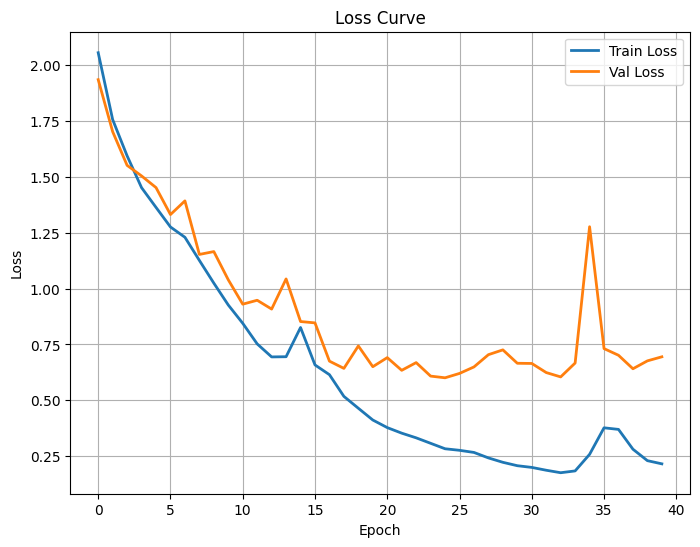

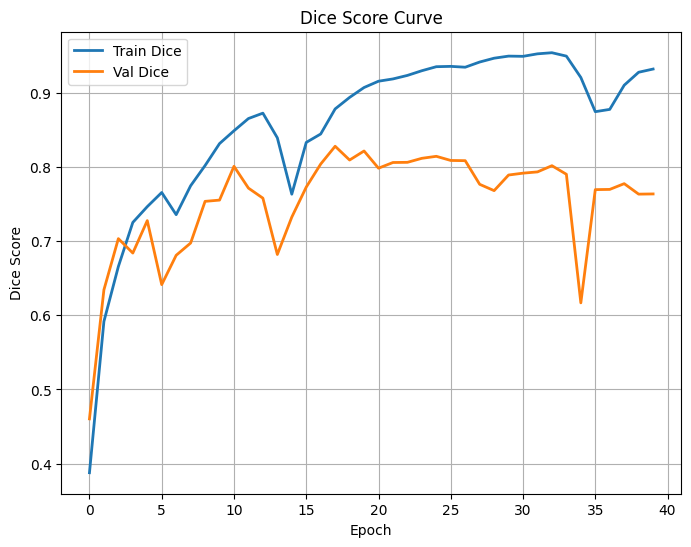

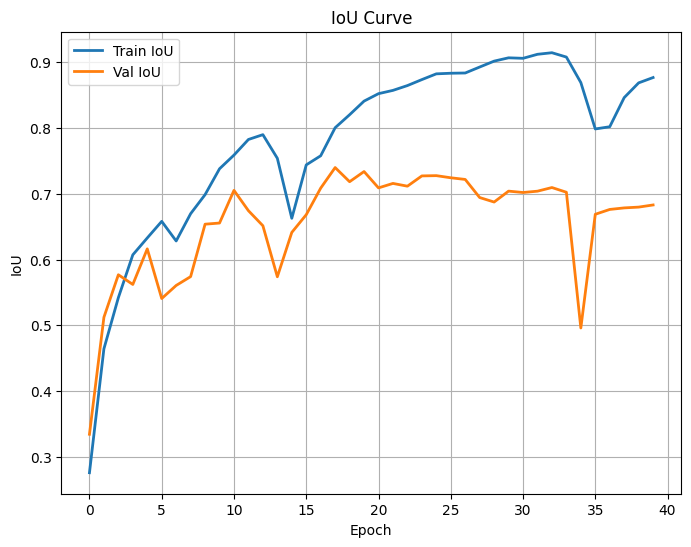

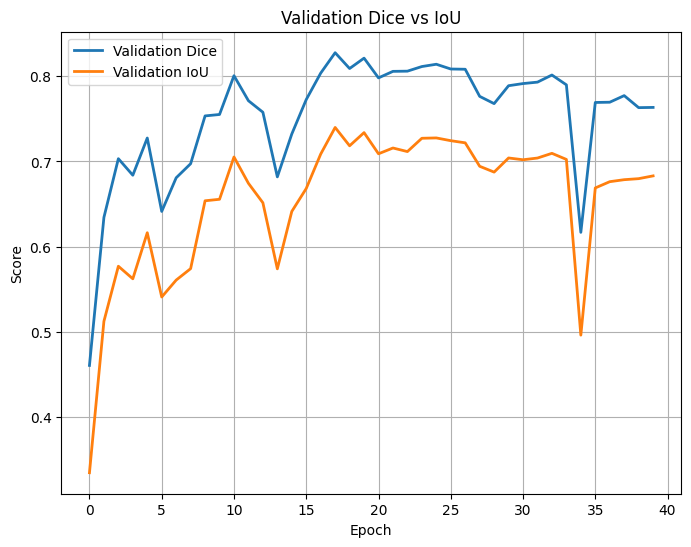

✅ All figures saved successfully!
📁 Location: /kaggle/working/UNet


In [24]:
import matplotlib.pyplot as plt
import os


save_dir = "/kaggle/working/UNet"
os.makedirs(save_dir, exist_ok=True)


plt.figure(figsize=(8, 6))
plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(val_losses, label="Val Loss", linewidth=2)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(save_dir, "loss_curve.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(save_dir, "loss_curve.pdf"),
            bbox_inches="tight")

plt.show()
plt.close()



plt.figure(figsize=(8, 6))
plt.plot(train_dices, label="Train Dice", linewidth=2)
plt.plot(val_dices, label="Val Dice", linewidth=2)
plt.title("Dice Score Curve")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(save_dir, "dice_curve.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(save_dir, "dice_curve.pdf"),
            bbox_inches="tight")

plt.show()
plt.close()



plt.figure(figsize=(8, 6))
plt.plot(train_ious, label="Train IoU", linewidth=2)
plt.plot(val_ious, label="Val IoU", linewidth=2)
plt.title("IoU Curve")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(save_dir, "iou_curve.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(save_dir, "iou_curve.pdf"),
            bbox_inches="tight")

plt.show()
plt.close()



plt.figure(figsize=(8, 6))
plt.plot(val_dices, label="Validation Dice", linewidth=2)
plt.plot(val_ious, label="Validation IoU", linewidth=2)
plt.title("Validation Dice vs IoU")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True)

plt.savefig(os.path.join(save_dir, "validation_dice_vs_iou.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(save_dir, "validation_dice_vs_iou.pdf"),
            bbox_inches="tight")

plt.show()
plt.close()

print("✅ All figures saved successfully!")
print(f"📁 Location: {save_dir}")

In [19]:
import torch
import numpy as np
from scipy.ndimage import binary_erosion, distance_transform_edt


def get_boundary(mask):
    mask = mask.astype(bool)
    return mask ^ binary_erosion(mask) if mask.any() else np.zeros_like(mask, dtype=bool)


def boundary_f1(pred, gt, tolerance=2):
    pred_b, gt_b = get_boundary(pred), get_boundary(gt)
    if not pred_b.any() or not gt_b.any():
        return 0.0
    gt_dist, pred_dist = distance_transform_edt(~gt_b), distance_transform_edt(~pred_b)
    precision = np.mean(gt_dist[pred_b] <= tolerance)
    recall = np.mean(pred_dist[gt_b] <= tolerance)
    return float(2 * precision * recall / (precision + recall + 1e-6))


def surface_distances(pred, gt):
    pred, gt = pred.astype(bool), gt.astype(bool)
    if not pred.any() or not gt.any():
        return np.nan, np.nan
    pred_b, gt_b = get_boundary(pred), get_boundary(gt)
    if not pred_b.any() or not gt_b.any():
        return np.nan, np.nan
    gt_dist, pred_dist = distance_transform_edt(~gt_b), distance_transform_edt(~pred_b)
    d_pred_gt, d_gt_pred = gt_dist[pred_b], pred_dist[gt_b]
    assd = (d_pred_gt.sum() + d_gt_pred.sum()) / (len(d_pred_gt) + len(d_gt_pred))
    hd95 = max(np.percentile(d_pred_gt, 95), np.percentile(d_gt_pred, 95))
    return float(assd), float(hd95)


def evaluate_segmentation(model, test_loader, device, threshold=0.4):
    model.eval().to(device)
    dice_all, iou_all, bf1_all, assd_all, hd95_all = [[], []], [[], []], [[], []], [[], []], [[], []]
    TP, FP, FN = [0, 0], [0, 0], [0, 0]
    total_correct = total_pixels = 0

    with torch.inference_mode():
        for imgs, masks, labels in test_loader:
            imgs = imgs.to(device, dtype=torch.float32, non_blocking=True)
            masks = masks.cpu()


            main_logits, _, _ = model(imgs)

            preds = (torch.sigmoid(main_logits) > threshold).squeeze(1).cpu()
            total_correct += (preds == masks).sum().item()
            total_pixels += masks.numel()
            del imgs

            for b in range(preds.size(0)):
                pred = preds[b].numpy().astype(np.uint8)
                gt = masks[b].numpy().astype(np.uint8)
                for c in range(2):
                    p, g = pred == c, gt == c
                    inter = np.logical_and(p, g).sum()
                    p_sum, g_sum = p.sum(), g.sum()
                    union = p_sum + g_sum
                    dice_all[c].append((2 * inter + 1e-6) / (union + 1e-6))
                    iou_all[c].append((inter + 1e-6) / (union - inter + 1e-6))
                    TP[c] += int(np.logical_and(p, g).sum())
                    FP[c] += int(np.logical_and(p, ~g).sum())
                    FN[c] += int(np.logical_and(~p, g).sum())
                    bf1_all[c].append(boundary_f1(p, g, tolerance=2))
                    assd, hd95 = surface_distances(p, g)
                    if not np.isnan(assd):
                        assd_all[c].append(assd)
                        hd95_all[c].append(hd95)

            del preds, masks
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    precision, recall, f1 = [], [], []
    for c in range(2):
        p = TP[c] / (TP[c] + FP[c] + 1e-6)
        r = TP[c] / (TP[c] + FN[c] + 1e-6)
        precision.append(p)
        recall.append(r)
        f1.append(2 * p * r / (p + r + 1e-6))

    def mean(x):
        return float(np.mean(x)) if x else 0.0

    def std(x):
        return float(np.std(x, ddof=1)) if len(x) > 1 else 0.0

    names = ["Background", "Polyp"]
    print("\n==================== Test Set Metrics ====================")
    print(f"Overall Pixel Accuracy : {total_correct / (total_pixels + 1e-6):.4f}")
    print("----------------------------------------------------------")
    print(f"{'Class':<15}{'Dice':>8}{'IoU':>8}{'BF1':>8}{'ASSD':>9}{'HD95':>9}{'F1':>8}")
    print("----------------------------------------------------------")

    metrics = {}
    for c in range(2):
        d, i, b, a, h = map(mean, [dice_all[c], iou_all[c], bf1_all[c], assd_all[c], hd95_all[c]])
        metrics[c] = {"dice": d, "iou": i, "bf1": b, "assd": a, "hd95": h}
        print(f"{names[c]:<15}{d:8.4f}{i:8.4f}{b:8.4f}{a:9.2f}{h:9.2f}{f1[c]:8.4f}")

    mean_dice = np.mean([metrics[0]["dice"], metrics[1]["dice"]])
    mean_iou = np.mean([metrics[0]["iou"], metrics[1]["iou"]])
    mean_bf1 = np.mean([metrics[0]["bf1"], metrics[1]["bf1"]])
    mean_assd = np.mean([metrics[0]["assd"], metrics[1]["assd"]])
    mean_hd95 = np.mean([metrics[0]["hd95"], metrics[1]["hd95"]])
    mean_f1 = np.mean(f1)

    print("----------------------------------------------------------")
    print(f"{'Mean':<15}{mean_dice:8.4f}{mean_iou:8.4f}{mean_bf1:8.4f}{mean_assd:9.2f}{mean_hd95:9.2f}{mean_f1:8.4f}")
    print("==========================================================")

    accuracy = total_correct / (total_pixels + 1e-6)
    print("\n── Polyp Class (Primary Metrics) ──")
    print(f"Dice       : {metrics[1]['dice']:.4f}")
    print(f"IoU        : {metrics[1]['iou']:.4f}")
    print(f"Boundary F1: {metrics[1]['bf1']:.4f}")
    print(f"ASSD       : {metrics[1]['assd']:.2f}")
    print(f"HD95       : {metrics[1]['hd95']:.2f}")
    print(f"Precision  : {precision[1]:.4f}")
    print(f"Recall     : {recall[1]:.4f}")
    print(f"F1         : {f1[1]:.4f}")
    print("==========================================================\n")

    return {
        "accuracy": accuracy,
        "mean_dice": mean_dice,
        "mean_iou": mean_iou,
        "mean_boundary_f1": mean_bf1,
        "mean_assd": mean_assd,
        "mean_hd95": mean_hd95,
        "mean_f1": mean_f1,
        "polyp_dice": metrics[1]["dice"],
        "polyp_iou": metrics[1]["iou"],
        "polyp_boundary_f1": metrics[1]["bf1"],
        "polyp_assd": metrics[1]["assd"],
        "polyp_hd95": metrics[1]["hd95"],
        "polyp_precision": precision[1],
        "polyp_recall": recall[1],
        "polyp_f1": f1[1]
    }


results = evaluate_segmentation(model, test_loader, device=device, threshold=0.4)


==================== Test Set Metrics ====================
Overall Pixel Accuracy : 0.9584
----------------------------------------------------------
Class              Dice     IoU     BF1     ASSD     HD95      F1
----------------------------------------------------------
Background       0.9747  0.9539  0.8956     1.67    14.62  0.9771
Polyp            0.7741  0.6963  0.5287     9.73    26.13  0.7787
----------------------------------------------------------
Mean             0.8744  0.8251  0.7121     5.70    20.38  0.8779

── Polyp Class (Primary Metrics) ──
Dice       : 0.7741
IoU        : 0.6963
Boundary F1: 0.5287
ASSD       : 9.73
HD95       : 26.13
Precision  : 0.7657
Recall     : 0.7921
F1         : 0.7787



Image:
/kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png

Ground Truth Mask:
/kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks/benign (1)_mask.png


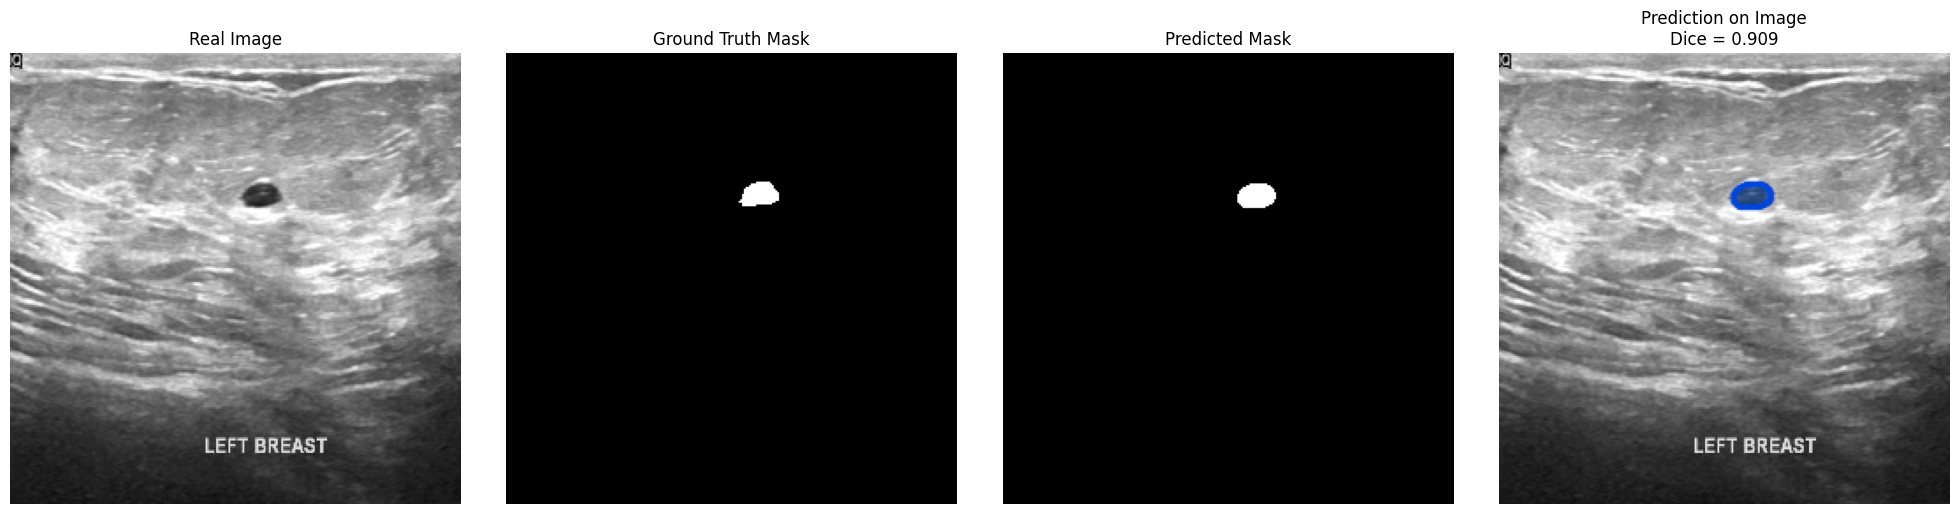


Visualization completed!
Image       : /kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png
GT Mask     : /kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks/benign (1)_mask.png
Dice        : 0.9091

Saved files:
/kaggle/working/UNet/XAI/real_image.png
/kaggle/working/UNet/XAI/ground_truth_mask.png
/kaggle/working/UNet/XAI/predicted_mask.png
/kaggle/working/UNet/XAI/predicted_mask_on_image.png


In [20]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

IMAGE_PATH = "/kaggle/input/datasets/anchord30/busi-dataset/BUSI/images/benign (1).png"

MASK_DIR = "/kaggle/input/datasets/anchord30/busi-dataset/BUSI/masks"

SAVE_DIR = "/kaggle/working/UNet/XAI"
os.makedirs(SAVE_DIR, exist_ok=True)

THRESHOLD = 0.4

MASK_COLOR = np.array([30, 120, 255], dtype=np.uint8)

BORDER_COLOR = (0, 70, 220)

MASK_ALPHA = 0.35
BORDER_WIDTH = 2

image_filename = os.path.basename(IMAGE_PATH)

base_name = os.path.splitext(image_filename)[0]

mask_path = os.path.join(
    MASK_DIR,
    base_name + "_mask.png"
)

if not os.path.exists(mask_path):

    found_mask = None

    for ext in [".jpg", ".jpeg", ".png", ".bmp"]:

        temp_path = os.path.join(
            MASK_DIR,
            base_name + "_mask" + ext
        )

        if os.path.exists(temp_path):
            found_mask = temp_path
            break

    if found_mask is None:
        raise FileNotFoundError(
            f"Mask not found for:\n{IMAGE_PATH}\n\n"
            f"Expected mask similar to:\n"
            f"{base_name}_mask.png"
        )

    mask_path = found_mask


print("Image:")
print(IMAGE_PATH)

print("\nGround Truth Mask:")
print(mask_path)

original_pil = Image.open(IMAGE_PATH).convert("RGB")

original_image = np.array(original_pil)

gt_pil = Image.open(mask_path).convert("L")

gt_mask_original = np.array(gt_pil)

gt_mask_original = (
    gt_mask_original > 127
).astype(np.uint8)

model_input = image_transform(original_pil)

model_input = model_input.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    output = model(model_input)

    if isinstance(output, (tuple, list)):
        output = output[0]

    probability = torch.sigmoid(output)

    predicted_mask = (
        probability > THRESHOLD
    ).long()

predicted_mask = predicted_mask.squeeze().cpu().numpy().astype(np.uint8)

output_h, output_w = predicted_mask.shape

gt_mask = cv2.resize(
    gt_mask_original,
    (output_w, output_h),
    interpolation=cv2.INTER_NEAREST
)

gt_mask = (
    gt_mask > 0
).astype(np.uint8)

display_image = cv2.resize(
    original_image,
    (output_w, output_h),
    interpolation=cv2.INTER_LINEAR
)

display_image = np.ascontiguousarray(
    display_image,
    dtype=np.uint8
)

gt_mask_display = (
    gt_mask * 255
).astype(np.uint8)

pred_mask_display = (
    predicted_mask * 255
).astype(np.uint8)

overlay = display_image.copy()

prediction_pixels = predicted_mask == 1

overlay[prediction_pixels] = (
    overlay[prediction_pixels].astype(np.float32)
    * (1 - MASK_ALPHA)
    +
    MASK_COLOR.astype(np.float32)
    * MASK_ALPHA
).astype(np.uint8)

contours, _ = cv2.findContours(
    predicted_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

overlay = np.ascontiguousarray(overlay)

cv2.drawContours(
    overlay,
    contours,
    -1,
    BORDER_COLOR,
    BORDER_WIDTH,
    lineType=cv2.LINE_AA
)

intersection = np.logical_and(
    predicted_mask == 1,
    gt_mask == 1
).sum()

pred_area = (
    predicted_mask == 1
).sum()

gt_area = (
    gt_mask == 1
).sum()

dice = (
    2.0 * intersection
    /
    (pred_area + gt_area + 1e-8)
)

save_path = os.path.join(
    SAVE_DIR,
    "real_image.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(display_image)

plt.title(
    "Real Image",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()

save_path = os.path.join(
    SAVE_DIR,
    "ground_truth_mask.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(
    gt_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title(
    "Ground Truth Mask",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()

save_path = os.path.join(
    SAVE_DIR,
    "predicted_mask.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(
    pred_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title(
    "Predicted Mask",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()

save_path = os.path.join(
    SAVE_DIR,
    "predicted_mask_on_image.png"
)

plt.figure(figsize=(7, 7))

plt.imshow(overlay)

plt.title(
    f"Predicted Mask on Image\nDice = {dice:.3f}",
    fontsize=16,
    fontweight="bold"
)

plt.axis("off")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

plt.close()

fig, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5)
)

axes[0].imshow(display_image)
axes[0].set_title("Real Image")

axes[1].imshow(
    gt_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[1].set_title("Ground Truth Mask")

axes[2].imshow(
    pred_mask_display,
    cmap="gray",
    vmin=0,
    vmax=255
)
axes[2].set_title("Predicted Mask")

axes[3].imshow(overlay)
axes[3].set_title(
    f"Prediction on Image\nDice = {dice:.3f}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

plt.close()

print("\n" + "=" * 60)
print("Visualization completed!")
print("=" * 60)

print(f"Image       : {IMAGE_PATH}")
print(f"GT Mask     : {mask_path}")
print(f"Dice        : {dice:.4f}")

print("\nSaved files:")

print(
    os.path.join(
        SAVE_DIR,
        "real_image.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "ground_truth_mask.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "predicted_mask.png"
    )
)

print(
    os.path.join(
        SAVE_DIR,
        "predicted_mask_on_image.png"
    )
)

print("=" * 60)

# Stop-gradient (GSR-UNet)

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm


class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1, d=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, s, p, dilation=d, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class RFB(nn.Module):

    def __init__(self, in_ch, out_ch):
        super().__init__()
        inter = out_ch // 4

        self.branch0 = nn.Sequential(
            ConvBNReLU(in_ch, inter, k=1, p=0),
        )
        self.branch1 = nn.Sequential(
            ConvBNReLU(in_ch, inter, k=1, p=0),
            ConvBNReLU(inter, inter, k=3, p=1, d=1),
        )
        self.branch2 = nn.Sequential(
            ConvBNReLU(in_ch, inter, k=1, p=0),
            ConvBNReLU(inter, inter, k=3, p=3, d=3),
        )
        self.branch3 = nn.Sequential(
            ConvBNReLU(in_ch, inter, k=1, p=0),
            ConvBNReLU(inter, inter, k=3, p=5, d=5),
        )
        self.fuse = ConvBNReLU(inter * 4, out_ch, k=1, p=0)
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        b0 = self.branch0(x)
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        out = self.fuse(torch.cat([b0, b1, b2, b3], dim=1))
        out = out + self.shortcut(x)
        return self.relu(out)


class AttentionGate(nn.Module):

    def __init__(self, g_ch, x_ch, inter_ch):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(g_ch, inter_ch, 1, bias=True),
            nn.BatchNorm2d(inter_ch),
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(x_ch, inter_ch, 1, bias=True),
            nn.BatchNorm2d(inter_ch),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, 1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        if g.shape[2:] != x.shape[2:]:
            g = F.interpolate(g, size=x.shape[2:], mode="bilinear", align_corners=False)
        psi = self.relu(self.W_g(g) + self.W_x(x))
        psi = self.psi(psi)
        return x * psi


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.att = AttentionGate(g_ch=in_ch, x_ch=skip_ch, inter_ch=skip_ch // 2)
        self.conv = nn.Sequential(
            ConvBNReLU(in_ch + skip_ch, out_ch),
            ConvBNReLU(out_ch, out_ch),
        )

    def forward(self, x, skip):
        x_up = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)
        skip_gated = self.att(g=x, x=skip)
        x_cat = torch.cat([x_up, skip_gated], dim=1)
        return self.conv(x_cat)



class UGBR(nn.Module):

    def __init__(self, feat_ch, hidden_ch=None):
        super().__init__()
        hidden_ch = hidden_ch or feat_ch

        self.sdf_head = nn.Sequential(
            ConvBNReLU(feat_ch, feat_ch // 2),
            ConvBNReLU(feat_ch // 2, feat_ch // 4),
            nn.Conv2d(feat_ch // 4, 1, 1),
            nn.Tanh()
        )

        self.refine = nn.Sequential(
            ConvBNReLU(feat_ch, hidden_ch),
            ConvBNReLU(hidden_ch, hidden_ch),
        )
        self.out_conv = nn.Conv2d(hidden_ch, 1, kernel_size=1)
        nn.init.zeros_(self.out_conv.weight)
        nn.init.zeros_(self.out_conv.bias)

        self.residual_scale = nn.Parameter(torch.tensor(0.05))     
        self.sdf_to_logit_scale = nn.Parameter(torch.tensor(0.05))

    def forward(self, coarse_logits, feat):

        sdf_pred = self.sdf_head(feat)


        boundary_mask = torch.exp(-(sdf_pred ** 2) / (2 * 0.10 ** 2))

        gated_feat = feat * (0.4 + 0.6 * boundary_mask)

        residual = self.out_conv(self.refine(gated_feat))

        refined_logits = (
            coarse_logits
            + self.residual_scale * residual
            + self.sdf_to_logit_scale * sdf_pred
        )
        return refined_logits, sdf_pred


class AttentionUNetRFB_UGBR(nn.Module):

    def __init__(self, out_channels=1, pretrained=True, decoder_channels=(256, 128, 64, 32)):
        super().__init__()

        resnet = tvm.resnet34(weights=tvm.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None)

        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)   # stride 2,  64ch
        self.pool = resnet.maxpool                                        # stride 4
        self.enc1 = resnet.layer1                                         # stride 4,  64ch
        self.enc2 = resnet.layer2                                         # stride 8, 128ch
        self.enc3 = resnet.layer3                                         # stride 16,256ch
        self.enc4 = resnet.layer4                                         # stride 32,512ch

        self.rfb = RFB(512, 512)

        c0, c1, c2, c3 = decoder_channels  # 256,128,64,32
        self.dec4 = DecoderBlock(in_ch=512, skip_ch=256, out_ch=c0)   # -> stride16
        self.dec3 = DecoderBlock(in_ch=c0,  skip_ch=128, out_ch=c1)   # -> stride8
        self.dec2 = DecoderBlock(in_ch=c1,  skip_ch=64,  out_ch=c2)   # -> stride4
        self.dec1 = DecoderBlock(in_ch=c2,  skip_ch=64,  out_ch=c3)   # -> stride2

        self.final_up = nn.Sequential(
            ConvBNReLU(c3, c3),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            ConvBNReLU(c3, c3),
        )

        self.head_main = nn.Conv2d(c3, out_channels, 1)     # coarse prediction (pre-UGBR)
        self.head_aux3 = nn.Conv2d(c1, out_channels, 1)     # deep supervision, stride8
        self.head_aux2 = nn.Conv2d(c2, out_channels, 1)     # deep supervision, stride4

        self.ugbr = UGBR(feat_ch=c3)

    def forward(self, x):
        H, W = x.shape[2:]

        s0 = self.stem(x)          
        s0p = self.pool(s0)       
        e1 = self.enc1(s0p)        
        e2 = self.enc2(e1)         
        e3 = self.enc3(e2)       
        e4 = self.enc4(e3)         

        bottleneck = self.rfb(e4)

        d4 = self.dec4(bottleneck, e3)   
        d3 = self.dec3(d4, e2)        
        d2 = self.dec2(d3, e1)          
        d1 = self.dec1(d2, s0)        
        out = self.final_up(d1)         

        coarse_logits = self.head_main(out)           
        refined_logits, sdf_pred = self.ugbr(coarse_logits, out)

        aux3_logits = self.head_aux3(d3)
        aux2_logits = self.head_aux2(d2)


        aux3_logits = F.interpolate(aux3_logits, size=(H, W), mode="bilinear", align_corners=False)
        aux2_logits = F.interpolate(aux2_logits, size=(H, W), mode="bilinear", align_corners=False)


        if refined_logits.shape[2:] != (H, W):
            refined_logits = F.interpolate(refined_logits, size=(H, W), mode="bilinear", align_corners=False)
            coarse_logits = F.interpolate(coarse_logits, size=(H, W), mode="bilinear", align_corners=False)
            sdf_pred = F.interpolate(sdf_pred, size=(H, W), mode="bilinear", align_corners=False)

        return refined_logits, [aux3_logits, aux2_logits, coarse_logits], sdf_pred


if __name__ == "__main__":
    model = AttentionUNetRFB_UGBR(out_channels=1, pretrained=True)
    x = torch.randn(2, 3, 352, 352)
    main_out, aux_outs, sdf_pred = model(x)
    print("refined (main):", main_out.shape)
    for i, a in enumerate(aux_outs):
        print(f"aux{i}:", a.shape)
    print("sdf_pred:", sdf_pred.shape, "range:", sdf_pred.min().item(), sdf_pred.max().item())
    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"Params: {n_params:.2f}M")

refined (main): torch.Size([2, 1, 352, 352])
aux0: torch.Size([2, 1, 352, 352])
aux1: torch.Size([2, 1, 352, 352])
aux2: torch.Size([2, 1, 352, 352])
sdf_pred: torch.Size([2, 1, 352, 352]) range: -0.9989392161369324 0.8182376623153687
Params: 25.84M


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from scipy.ndimage import distance_transform_edt

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


class CombinedLoss(nn.Module):
    def __init__(self, dice_weight=0.7, bce_weight=0.3):
        super().__init__()
        self.dice = DiceLoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.dw = dice_weight
        self.bw = bce_weight

    def forward(self, logits, targets):
        if targets.dim() == 3:
            targets = targets.unsqueeze(1)
        targets = targets.float()
        return self.dw * self.dice(logits, targets) + \
               self.bw * self.bce(logits, targets)


def dice_score(logits, targets, smooth=1e-6, thresh=0.4):
    probs = torch.sigmoid(logits)
    preds = (probs > thresh).float()
    if targets.dim() == 3:
        targets = targets.unsqueeze(1)
    targets = targets.float()
    intersection = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
    dice = (2 * intersection + smooth) / (union + smooth)
    return dice.mean()


def iou_score(logits, targets, smooth=1e-6, thresh=0.4):
    probs = torch.sigmoid(logits)
    preds = (probs > thresh).float()
    if targets.dim() == 3:
        targets = targets.unsqueeze(1)
    targets = targets.float()
    intersection = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou.mean()


def deep_supervision_loss(criterion, main_logits, aux_logits_list, masks, aux_weight=0.4):
    loss = criterion(main_logits, masks)
    for aux in aux_logits_list:
        loss = loss + aux_weight * criterion(aux, masks)
    return loss


def compute_sdf_target(masks, clip_dist=15.0):
    device = masks.device
    if masks.dim() == 4:
        masks_np = masks.squeeze(1).detach().cpu().numpy()
    else:
        masks_np = masks.detach().cpu().numpy()

    B, H, W = masks_np.shape
    sdf = np.zeros((B, 1, H, W), dtype=np.float32)
    for b in range(B):
        m = masks_np[b] > 0.5
        if m.any() and (~m).any():
            dist_in = distance_transform_edt(m)
            dist_out = distance_transform_edt(~m)
            signed = np.where(m, dist_in, -dist_out)
        elif m.all():
            signed = np.full((H, W), clip_dist, dtype=np.float32)
        else:
            signed = np.full((H, W), -clip_dist, dtype=np.float32)
        sdf[b, 0] = np.clip(signed, -clip_dist, clip_dist) / clip_dist

    return torch.from_numpy(sdf).to(device)


def sdf_supervision_loss(sdf_pred, masks, clip_dist=15.0):
    target = compute_sdf_target(masks, clip_dist=clip_dist)
    if target.shape[2:] != sdf_pred.shape[2:]:
        target = F.interpolate(target, size=sdf_pred.shape[2:], mode="bilinear", align_corners=False)
    return F.smooth_l1_loss(sdf_pred, target)


SDF_LOSS_WEIGHT = 0.06

class EarlyStopping:
    def __init__(self, patience=15, verbose=True):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), "best_model.pth")
            if self.verbose:
                print(f"  Val loss improved to {val_loss:.4f} — model saved.")
        else:
            self.counter += 1
            if self.verbose:
                print(f"  No improvement: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                print("  Early stopping triggered.")
                self.stop = True


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttentionUNetRFB_UGBR(out_channels=1, pretrained=True)
model = model.to(device)

criterion = CombinedLoss().to(device)

num_epochs = 200
aux_weight = 0.6

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-6
)

early_stopping = EarlyStopping(patience=15, verbose=True)

train_losses, val_losses = [], []
train_dices, val_dices = [], []
train_ious, val_ious = [], []

for epoch in range(num_epochs):

    model.train()
    train_loss = 0.0
    train_dice = 0.0
    train_iou = 0.0

    for imgs, masks, labels in train_loader:
        imgs = imgs.to(device, dtype=torch.float32)
        masks = masks.to(device, dtype=torch.float32)

        optimizer.zero_grad(set_to_none=True)

        main_logits, aux_logits, sdf_pred = model(imgs)

        loss = deep_supervision_loss(criterion, main_logits, aux_logits, masks, aux_weight)
        loss = loss + SDF_LOSS_WEIGHT * sdf_supervision_loss(sdf_pred, masks)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_dice += dice_score(main_logits, masks).item()
        train_iou += iou_score(main_logits, masks).item()

    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    val_iou = 0.0

    with torch.no_grad():
        for imgs, masks, labels in val_loader:
            imgs = imgs.to(device, dtype=torch.float32)
            masks = masks.to(device, dtype=torch.float32)

            main_logits, aux_logits, sdf_pred = model(imgs)

            loss = deep_supervision_loss(criterion, main_logits, aux_logits, masks, aux_weight)
            loss = loss + SDF_LOSS_WEIGHT * sdf_supervision_loss(sdf_pred, masks)

            val_loss += loss.item()
            val_dice += dice_score(main_logits, masks).item()
            val_iou += iou_score(main_logits, masks).item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_train_dice = train_dice / len(train_loader)
    avg_val_dice = val_dice / len(val_loader)
    avg_train_iou = train_iou / len(train_loader)
    avg_val_iou = val_iou / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_dices.append(avg_train_dice)
    val_dices.append(avg_val_dice)
    train_ious.append(avg_train_iou)
    val_ious.append(avg_val_iou)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Dice: {avg_val_dice:.4f} | "
        f"IoU: {avg_val_iou:.4f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.2e}"
    )

    scheduler.step()

    early_stopping(avg_val_loss, model)
    if early_stopping.stop:
        print(f"\nTraining stopped early at epoch {epoch+1}.")
        break

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model = model.to(device)
print("\nBest model loaded for evaluation.")

Epoch [1/200] Train Loss: 1.9052 | Val Loss: 1.6947 | Dice: 0.5577 | IoU: 0.4186 | LR: 3.00e-04
  Val loss improved to 1.6947 — model saved.
Epoch [2/200] Train Loss: 1.5950 | Val Loss: 1.5074 | Dice: 0.6377 | IoU: 0.5103 | LR: 3.00e-04
  Val loss improved to 1.5074 — model saved.
Epoch [3/200] Train Loss: 1.4326 | Val Loss: 1.4031 | Dice: 0.6573 | IoU: 0.5305 | LR: 3.00e-04
  Val loss improved to 1.4031 — model saved.
Epoch [4/200] Train Loss: 1.2938 | Val Loss: 1.2972 | Dice: 0.7262 | IoU: 0.6022 | LR: 3.00e-04
  Val loss improved to 1.2972 — model saved.
Epoch [5/200] Train Loss: 1.2058 | Val Loss: 1.2702 | Dice: 0.7137 | IoU: 0.5989 | LR: 3.00e-04
  Val loss improved to 1.2702 — model saved.
Epoch [6/200] Train Loss: 1.1251 | Val Loss: 1.2765 | Dice: 0.6708 | IoU: 0.5486 | LR: 3.00e-04
  No improvement: 1/15
Epoch [7/200] Train Loss: 1.0303 | Val Loss: 1.1400 | Dice: 0.7192 | IoU: 0.5957 | LR: 2.99e-04
  Val loss improved to 1.1400 — model saved.
Epoch [8/200] Train Loss: 0.9291 | 

In [15]:
import torch
import numpy as np
from scipy.ndimage import binary_erosion, distance_transform_edt


def get_boundary(mask):
    mask = mask.astype(bool)

    if mask.any():
        return mask ^ binary_erosion(mask)

    return np.zeros_like(mask, dtype=bool)


def boundary_f1(pred, gt, tolerance=2):
    pred_b = get_boundary(pred)
    gt_b = get_boundary(gt)

    if not pred_b.any() or not gt_b.any():
        return 0.0

    gt_dist = distance_transform_edt(~gt_b)
    pred_dist = distance_transform_edt(~pred_b)

    precision = np.mean(gt_dist[pred_b] <= tolerance)
    recall = np.mean(pred_dist[gt_b] <= tolerance)

    return float(
        2 * precision * recall /
        (precision + recall + 1e-6)
    )


def surface_distances(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)


    if not pred.any() or not gt.any():
        return np.nan, np.nan

    pred_b = get_boundary(pred)
    gt_b = get_boundary(gt)

    if not pred_b.any() or not gt_b.any():
        return np.nan, np.nan

    gt_dist = distance_transform_edt(~gt_b)
    pred_dist = distance_transform_edt(~pred_b)

    d_pred_gt = gt_dist[pred_b]
    d_gt_pred = pred_dist[gt_b]


    assd = (
        d_pred_gt.sum() + d_gt_pred.sum()
    ) / (
        len(d_pred_gt) + len(d_gt_pred)
    )


    hd95 = max(
        np.percentile(d_pred_gt, 95),
        np.percentile(d_gt_pred, 95)
    )

    return float(assd), float(hd95)


def evaluate_segmentation(
    model,
    test_loader,
    device,
    threshold=0.4
):

    model.eval()
    model.to(device)

    dice_all = [[], []]
    iou_all = [[], []]
    bf1_all = [[], []]
    assd_all = [[], []]
    hd95_all = [[], []]

    # Global confusion statistics
    TP = [0, 0]
    FP = [0, 0]
    FN = [0, 0]

    total_correct = 0
    total_pixels = 0

    with torch.inference_mode():

        for imgs, masks, labels in test_loader:

            imgs = imgs.to(
                device,
                dtype=torch.float32,
                non_blocking=True
            )

            masks = masks.cpu()

            

            main_logits, _, _ = model(imgs)

           

            preds = (
                torch.sigmoid(main_logits) > threshold
            ).squeeze(1).cpu()

            

            total_correct += (
                (preds == masks).sum().item()
            )

            total_pixels += masks.numel()

            del imgs

       

            for b in range(preds.size(0)):

                pred = (
                    preds[b]
                    .numpy()
                    .astype(np.uint8)
                )

                gt = (
                    masks[b]
                    .numpy()
                    .astype(np.uint8)
                )

              

                for c in range(2):

                    p = pred == c
                    g = gt == c

                  

                    inter = np.logical_and(
                        p, g
                    ).sum()

                    p_sum = p.sum()
                    g_sum = g.sum()

                    union = p_sum + g_sum

                    dice = (
                        2 * inter + 1e-6
                    ) / (
                        union + 1e-6
                    )

                    dice_all[c].append(dice)

                    

                    iou = (
                        inter + 1e-6
                    ) / (
                        union - inter + 1e-6
                    )

                    iou_all[c].append(iou)

                   

                    TP[c] += int(
                        np.logical_and(p, g).sum()
                    )

                    FP[c] += int(
                        np.logical_and(p, ~g).sum()
                    )

                    FN[c] += int(
                        np.logical_and(~p, g).sum()
                    )

                   

                    bf1 = boundary_f1(
                        p,
                        g,
                        tolerance=2
                    )

                    bf1_all[c].append(bf1)

                  

                    assd, hd95 = surface_distances(
                        p,
                        g
                    )

                    if not np.isnan(assd):

                        assd_all[c].append(assd)
                        hd95_all[c].append(hd95)

            del preds, masks

            if torch.cuda.is_available():
                torch.cuda.empty_cache()



    precision = []
    recall = []
    f1 = []

    for c in range(2):

        p = TP[c] / (
            TP[c] + FP[c] + 1e-6
        )

        r = TP[c] / (
            TP[c] + FN[c] + 1e-6
        )

        f = (
            2 * p * r
        ) / (
            p + r + 1e-6
        )

        precision.append(p)
        recall.append(r)
        f1.append(f)


    def mean(x):
        return (
            float(np.mean(x))
            if len(x) > 0
            else 0.0
        )

    def std(x):
        return (
            float(np.std(x, ddof=1))
            if len(x) > 1
            else 0.0
        )



    names = [
        "Background",
        "Polyp"
    ]


    print(
        "\n==================== Test Set Metrics ===================="
    )

    accuracy = (
        total_correct /
        (total_pixels + 1e-6)
    )

    print(
        f"Overall Pixel Accuracy : {accuracy:.4f}"
    )

    print(
        "----------------------------------------------------------"
    )

    print(
        f"{'Class':<15}"
        f"{'Dice':>8}"
        f"{'IoU':>8}"
        f"{'BF1':>8}"
        f"{'ASSD':>9}"
        f"{'HD95':>9}"
        f"{'F1':>8}"
    )

    print(
        "----------------------------------------------------------"
    )


    metrics = {}

    for c in range(2):

        d = mean(dice_all[c])
        i = mean(iou_all[c])
        b = mean(bf1_all[c])
        a = mean(assd_all[c])
        h = mean(hd95_all[c])

        metrics[c] = {
            "dice": d,
            "iou": i,
            "bf1": b,
            "assd": a,
            "hd95": h
        }

        print(
            f"{names[c]:<15}"
            f"{d:8.4f}"
            f"{i:8.4f}"
            f"{b:8.4f}"
            f"{a:9.2f}"
            f"{h:9.2f}"
            f"{f1[c]:8.4f}"
        )


    mean_dice = np.mean([
        metrics[0]["dice"],
        metrics[1]["dice"]
    ])

    mean_iou = np.mean([
        metrics[0]["iou"],
        metrics[1]["iou"]
    ])

    mean_bf1 = np.mean([
        metrics[0]["bf1"],
        metrics[1]["bf1"]
    ])

    mean_assd = np.mean([
        metrics[0]["assd"],
        metrics[1]["assd"]
    ])

    mean_hd95 = np.mean([
        metrics[0]["hd95"],
        metrics[1]["hd95"]
    ])

    mean_f1 = np.mean(f1)

    print(
        "----------------------------------------------------------"
    )

    print(
        f"{'Mean':<15}"
        f"{mean_dice:8.4f}"
        f"{mean_iou:8.4f}"
        f"{mean_bf1:8.4f}"
        f"{mean_assd:9.2f}"
        f"{mean_hd95:9.2f}"
        f"{mean_f1:8.4f}"
    )

    print(
        "=========================================================="
    )


    print(
        "\n── Polyp Class (Primary Metrics) ──"
    )

    print(
        f"Dice       : {metrics[1]['dice']:.4f}"
    )

    print(
        f"IoU        : {metrics[1]['iou']:.4f}"
    )

    print(
        f"Boundary F1: {metrics[1]['bf1']:.4f}"
    )

    print(
        f"ASSD       : {metrics[1]['assd']:.2f}"
    )

    print(
        f"HD95       : {metrics[1]['hd95']:.2f}"
    )

    print(
        f"Precision  : {precision[1]:.4f}"
    )

    print(
        f"Recall     : {recall[1]:.4f}"
    )

    print(
        f"F1         : {f1[1]:.4f}"
    )

    print(
        "==========================================================\n"
    )


    return {
        "accuracy": accuracy,

        "mean_dice": mean_dice,
        "mean_iou": mean_iou,
        "mean_boundary_f1": mean_bf1,
        "mean_assd": mean_assd,
        "mean_hd95": mean_hd95,
        "mean_f1": mean_f1,

        "polyp_dice": metrics[1]["dice"],
        "polyp_iou": metrics[1]["iou"],
        "polyp_boundary_f1": metrics[1]["bf1"],
        "polyp_assd": metrics[1]["assd"],
        "polyp_hd95": metrics[1]["hd95"],
        "polyp_precision": precision[1],
        "polyp_recall": recall[1],
        "polyp_f1": f1[1]
    }


results = evaluate_segmentation(
    model,
    test_loader,
    device=device,
    threshold=0.4
)


==================== Test Set Metrics ====================
Overall Pixel Accuracy : 0.9551
----------------------------------------------------------
Class              Dice     IoU     BF1     ASSD     HD95      F1
----------------------------------------------------------
Background       0.9725  0.9502  0.8917     1.75    14.87  0.9752
Polyp            0.7633  0.6838  0.5205    10.28    26.89  0.7646
----------------------------------------------------------
Mean             0.8679  0.8170  0.7061     6.01    20.88  0.8699

── Polyp Class (Primary Metrics) ──
Dice       : 0.7633
IoU        : 0.6838
Boundary F1: 0.5205
ASSD       : 10.28
HD95       : 26.89
Precision  : 0.7405
Recall     : 0.7902
F1         : 0.7646



# SDF Loss = 0.0 (GSR-UNet)

In [16]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm



class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1, d=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, s, p, dilation=d, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class RFB(nn.Module):

    def __init__(self, in_ch, out_ch):
        super().__init__()
        inter = out_ch // 4

        self.branch0 = nn.Sequential(
            ConvBNReLU(in_ch, inter, k=1, p=0),
        )
        self.branch1 = nn.Sequential(
            ConvBNReLU(in_ch, inter, k=1, p=0),
            ConvBNReLU(inter, inter, k=3, p=1, d=1),
        )
        self.branch2 = nn.Sequential(
            ConvBNReLU(in_ch, inter, k=1, p=0),
            ConvBNReLU(inter, inter, k=3, p=3, d=3),
        )
        self.branch3 = nn.Sequential(
            ConvBNReLU(in_ch, inter, k=1, p=0),
            ConvBNReLU(inter, inter, k=3, p=5, d=5),
        )
        self.fuse = ConvBNReLU(inter * 4, out_ch, k=1, p=0)
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        b0 = self.branch0(x)
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        out = self.fuse(torch.cat([b0, b1, b2, b3], dim=1))
        out = out + self.shortcut(x)
        return self.relu(out)


class AttentionGate(nn.Module):

    def __init__(self, g_ch, x_ch, inter_ch):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(g_ch, inter_ch, 1, bias=True),
            nn.BatchNorm2d(inter_ch),
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(x_ch, inter_ch, 1, bias=True),
            nn.BatchNorm2d(inter_ch),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, 1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        if g.shape[2:] != x.shape[2:]:
            g = F.interpolate(g, size=x.shape[2:], mode="bilinear", align_corners=False)
        psi = self.relu(self.W_g(g) + self.W_x(x))
        psi = self.psi(psi)
        return x * psi


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.att = AttentionGate(g_ch=in_ch, x_ch=skip_ch, inter_ch=skip_ch // 2)
        self.conv = nn.Sequential(
            ConvBNReLU(in_ch + skip_ch, out_ch),
            ConvBNReLU(out_ch, out_ch),
        )

    def forward(self, x, skip):
        x_up = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)
        skip_gated = self.att(g=x, x=skip)
        x_cat = torch.cat([x_up, skip_gated], dim=1)
        return self.conv(x_cat)


class UGBR(nn.Module):

    def __init__(self, feat_ch, hidden_ch=None):
        super().__init__()
        hidden_ch = hidden_ch or feat_ch

        self.sdf_head = nn.Sequential(
            ConvBNReLU(feat_ch, feat_ch // 2),
            ConvBNReLU(feat_ch // 2, feat_ch // 4),
            nn.Conv2d(feat_ch // 4, 1, 1),
            nn.Tanh()
        )


        self.refine = nn.Sequential(
            ConvBNReLU(feat_ch, hidden_ch),
            ConvBNReLU(hidden_ch, hidden_ch),
        )
        self.out_conv = nn.Conv2d(hidden_ch, 1, kernel_size=1)
        nn.init.zeros_(self.out_conv.weight)
        nn.init.zeros_(self.out_conv.bias)

        # Very important: both scales start small
        self.residual_scale = nn.Parameter(torch.tensor(0.05))     
        self.sdf_to_logit_scale = nn.Parameter(torch.tensor(0.05))

    def forward(self, coarse_logits, feat):

        sdf_pred = self.sdf_head(feat.detach())

        boundary_mask = torch.exp(-(sdf_pred ** 2) / (2 * 0.10 ** 2))

        gated_feat = feat * (0.4 + 0.6 * boundary_mask)

        residual = self.out_conv(self.refine(gated_feat))

        refined_logits = (
            coarse_logits
            + self.residual_scale * residual
            + self.sdf_to_logit_scale * sdf_pred
        )
        return refined_logits, sdf_pred


class AttentionUNetRFB_UGBR(nn.Module):

    def __init__(self, out_channels=1, pretrained=True, decoder_channels=(256, 128, 64, 32)):
        super().__init__()

        resnet = tvm.resnet34(weights=tvm.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None)

        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)   
        self.pool = resnet.maxpool                                      
        self.enc1 = resnet.layer1                                     
        self.enc2 = resnet.layer2                                         
        self.enc3 = resnet.layer3                                     
        self.enc4 = resnet.layer4                                        

        self.rfb = RFB(512, 512)

        c0, c1, c2, c3 = decoder_channels  
        self.dec4 = DecoderBlock(in_ch=512, skip_ch=256, out_ch=c0)   
        self.dec3 = DecoderBlock(in_ch=c0,  skip_ch=128, out_ch=c1)   
        self.dec2 = DecoderBlock(in_ch=c1,  skip_ch=64,  out_ch=c2)   
        self.dec1 = DecoderBlock(in_ch=c2,  skip_ch=64,  out_ch=c3)   

        self.final_up = nn.Sequential(
            ConvBNReLU(c3, c3),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            ConvBNReLU(c3, c3),
        )

        self.head_main = nn.Conv2d(c3, out_channels, 1)     
        self.head_aux3 = nn.Conv2d(c1, out_channels, 1)     
        self.head_aux2 = nn.Conv2d(c2, out_channels, 1)     

        self.ugbr = UGBR(feat_ch=c3)

    def forward(self, x):
        H, W = x.shape[2:]

        s0 = self.stem(x)          
        s0p = self.pool(s0)   
        e1 = self.enc1(s0p)        
        e2 = self.enc2(e1)         
        e3 = self.enc3(e2)        
        e4 = self.enc4(e3)         

        bottleneck = self.rfb(e4)

        d4 = self.dec4(bottleneck, e3)   
        d3 = self.dec3(d4, e2)          
        d2 = self.dec2(d3, e1)           
        d1 = self.dec1(d2, s0)           
        out = self.final_up(d1)          

        coarse_logits = self.head_main(out)                 
        refined_logits, sdf_pred = self.ugbr(coarse_logits, out)

        aux3_logits = self.head_aux3(d3)
        aux2_logits = self.head_aux2(d2)

        aux3_logits = F.interpolate(aux3_logits, size=(H, W), mode="bilinear", align_corners=False)
        aux2_logits = F.interpolate(aux2_logits, size=(H, W), mode="bilinear", align_corners=False)

        if refined_logits.shape[2:] != (H, W):
            refined_logits = F.interpolate(refined_logits, size=(H, W), mode="bilinear", align_corners=False)
            coarse_logits = F.interpolate(coarse_logits, size=(H, W), mode="bilinear", align_corners=False)
            sdf_pred = F.interpolate(sdf_pred, size=(H, W), mode="bilinear", align_corners=False)

        return refined_logits, [aux3_logits, aux2_logits, coarse_logits], sdf_pred


if __name__ == "__main__":
    model = AttentionUNetRFB_UGBR(out_channels=1, pretrained=True)
    x = torch.randn(2, 3, 352, 352)
    main_out, aux_outs, sdf_pred = model(x)
    print("refined (main):", main_out.shape)
    for i, a in enumerate(aux_outs):
        print(f"aux{i}:", a.shape)
    print("sdf_pred:", sdf_pred.shape, "range:", sdf_pred.min().item(), sdf_pred.max().item())
    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"Params: {n_params:.2f}M")

refined (main): torch.Size([2, 1, 352, 352])
aux0: torch.Size([2, 1, 352, 352])
aux1: torch.Size([2, 1, 352, 352])
aux2: torch.Size([2, 1, 352, 352])
sdf_pred: torch.Size([2, 1, 352, 352]) range: -0.8304728269577026 0.9979786276817322
Params: 25.84M


In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from scipy.ndimage import distance_transform_edt

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


class CombinedLoss(nn.Module):
    def __init__(self, dice_weight=0.7, bce_weight=0.3):
        super().__init__()
        self.dice = DiceLoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.dw = dice_weight
        self.bw = bce_weight

    def forward(self, logits, targets):
        if targets.dim() == 3:
            targets = targets.unsqueeze(1)
        targets = targets.float()
        return self.dw * self.dice(logits, targets) + \
               self.bw * self.bce(logits, targets)


def dice_score(logits, targets, smooth=1e-6, thresh=0.4):
    probs = torch.sigmoid(logits)
    preds = (probs > thresh).float()
    if targets.dim() == 3:
        targets = targets.unsqueeze(1)
    targets = targets.float()
    intersection = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
    dice = (2 * intersection + smooth) / (union + smooth)
    return dice.mean()


def iou_score(logits, targets, smooth=1e-6, thresh=0.4):
    probs = torch.sigmoid(logits)
    preds = (probs > thresh).float()
    if targets.dim() == 3:
        targets = targets.unsqueeze(1)
    targets = targets.float()
    intersection = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou.mean()
 
 
def deep_supervision_loss(criterion, main_logits, aux_logits_list, masks, aux_weight=0.4):
    loss = criterion(main_logits, masks)
    for aux in aux_logits_list:
        loss = loss + aux_weight * criterion(aux, masks)
    return loss
 
 
def compute_sdf_target(masks, clip_dist=15.0):
    device = masks.device
    if masks.dim() == 4:
        masks_np = masks.squeeze(1).detach().cpu().numpy()
    else:
        masks_np = masks.detach().cpu().numpy()
 
    B, H, W = masks_np.shape
    sdf = np.zeros((B, 1, H, W), dtype=np.float32)
    for b in range(B):
        m = masks_np[b] > 0.5
        if m.any() and (~m).any():
            dist_in = distance_transform_edt(m)      
            dist_out = distance_transform_edt(~m)     
            signed = np.where(m, dist_in, -dist_out)
        elif m.all():
            signed = np.full((H, W), clip_dist, dtype=np.float32)
        else: 
            signed = np.full((H, W), -clip_dist, dtype=np.float32)
        sdf[b, 0] = np.clip(signed, -clip_dist, clip_dist) / clip_dist
 
    return torch.from_numpy(sdf).to(device)
 
 
def sdf_supervision_loss(sdf_pred, masks, clip_dist=15.0):
    target = compute_sdf_target(masks, clip_dist=clip_dist)
    if target.shape[2:] != sdf_pred.shape[2:]:
        target = F.interpolate(target, size=sdf_pred.shape[2:], mode="bilinear", align_corners=False)
    return F.smooth_l1_loss(sdf_pred, target)
 
 
SDF_LOSS_WEIGHT = 0.00 

class EarlyStopping:
    def __init__(self, patience=15, verbose=True):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.stop = False
 
    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), "best_model.pth")
            if self.verbose:
                print(f"  Val loss improved to {val_loss:.4f} — model saved.")
        else:
            self.counter += 1
            if self.verbose:
                print(f"  No improvement: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                print("  Early stopping triggered.")
                self.stop = True
 
 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 
model = AttentionUNetRFB_UGBR(out_channels=1, pretrained=True)
model = model.to(device)
 
criterion = CombinedLoss().to(device)
 
num_epochs = 200
aux_weight = 0.6  
 
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)
 
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-6
)
 
early_stopping = EarlyStopping(patience=15, verbose=True)
 

train_losses, val_losses = [], []
train_dices, val_dices = [], []
train_ious, val_ious = [], []
 

for epoch in range(num_epochs):

    model.train()
    train_loss = 0.0
    train_dice = 0.0
    train_iou = 0.0
 
    for imgs, masks, labels in train_loader:
        imgs = imgs.to(device, dtype=torch.float32)
        masks = masks.to(device, dtype=torch.float32)  
 
        optimizer.zero_grad(set_to_none=True)
 

        main_logits, aux_logits, sdf_pred = model(imgs)
 
        loss = deep_supervision_loss(criterion, main_logits, aux_logits, masks, aux_weight)
        
        loss = loss + SDF_LOSS_WEIGHT * sdf_supervision_loss(sdf_pred, masks)
 
        loss.backward()
        optimizer.step()
 
        train_loss += loss.item()
        train_dice += dice_score(main_logits, masks).item()
        train_iou += iou_score(main_logits, masks).item()
 

    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    val_iou = 0.0
 
    with torch.no_grad():
        for imgs, masks, labels in val_loader:
            imgs = imgs.to(device, dtype=torch.float32)
            masks = masks.to(device, dtype=torch.float32)
 
            main_logits, aux_logits, sdf_pred = model(imgs)
 
            loss = deep_supervision_loss(criterion, main_logits, aux_logits, masks, aux_weight)
            
 
            val_loss += loss.item()
            val_dice += dice_score(main_logits, masks).item()
            val_iou += iou_score(main_logits, masks).item()
 

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_train_dice = train_dice / len(train_loader)
    avg_val_dice = val_dice / len(val_loader)
    avg_train_iou = train_iou / len(train_loader)
    avg_val_iou = val_iou / len(val_loader)
 

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_dices.append(avg_train_dice)
    val_dices.append(avg_val_dice)
    train_ious.append(avg_train_iou)
    val_ious.append(avg_val_iou)
 

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Dice: {avg_val_dice:.4f} | "
        f"IoU: {avg_val_iou:.4f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.2e}"
    )
 

    scheduler.step()
 

    early_stopping(avg_val_loss, model)
    if early_stopping.stop:
        print(f"\nTraining stopped early at epoch {epoch+1}.")
        break
 

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model = model.to(device)
print("\nBest model loaded for evaluation.")

Epoch [1/200] Train Loss: 1.9160 | Val Loss: 1.7759 | Dice: 0.4443 | IoU: 0.3187 | LR: 3.00e-04
  Val loss improved to 1.7759 — model saved.
Epoch [2/200] Train Loss: 1.6121 | Val Loss: 1.5464 | Dice: 0.6503 | IoU: 0.5202 | LR: 3.00e-04
  Val loss improved to 1.5464 — model saved.
Epoch [3/200] Train Loss: 1.4460 | Val Loss: 1.3915 | Dice: 0.6999 | IoU: 0.5774 | LR: 3.00e-04
  Val loss improved to 1.3915 — model saved.
Epoch [4/200] Train Loss: 1.3184 | Val Loss: 1.3164 | Dice: 0.6777 | IoU: 0.5483 | LR: 3.00e-04
  Val loss improved to 1.3164 — model saved.
Epoch [5/200] Train Loss: 1.2147 | Val Loss: 1.2855 | Dice: 0.7547 | IoU: 0.6392 | LR: 3.00e-04
  Val loss improved to 1.2855 — model saved.
Epoch [6/200] Train Loss: 1.1156 | Val Loss: 1.2858 | Dice: 0.6889 | IoU: 0.5756 | LR: 3.00e-04
  No improvement: 1/15
Epoch [7/200] Train Loss: 1.0121 | Val Loss: 1.1104 | Dice: 0.7181 | IoU: 0.5991 | LR: 2.99e-04
  Val loss improved to 1.1104 — model saved.
Epoch [8/200] Train Loss: 0.9377 | 

In [21]:
import torch
import numpy as np
from scipy.ndimage import binary_erosion, distance_transform_edt


def get_boundary(mask):
    mask = mask.astype(bool)

    if mask.any():
        return mask ^ binary_erosion(mask)

    return np.zeros_like(mask, dtype=bool)


def boundary_f1(pred, gt, tolerance=2):
    pred_b = get_boundary(pred)
    gt_b = get_boundary(gt)

    if not pred_b.any() or not gt_b.any():
        return 0.0

    gt_dist = distance_transform_edt(~gt_b)
    pred_dist = distance_transform_edt(~pred_b)

    precision = np.mean(gt_dist[pred_b] <= tolerance)
    recall = np.mean(pred_dist[gt_b] <= tolerance)

    return float(
        2 * precision * recall /
        (precision + recall + 1e-6)
    )



def surface_distances(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    if not pred.any() or not gt.any():
        return np.nan, np.nan

    pred_b = get_boundary(pred)
    gt_b = get_boundary(gt)

    if not pred_b.any() or not gt_b.any():
        return np.nan, np.nan

    gt_dist = distance_transform_edt(~gt_b)
    pred_dist = distance_transform_edt(~pred_b)

    d_pred_gt = gt_dist[pred_b]
    d_gt_pred = pred_dist[gt_b]

    assd = (
        d_pred_gt.sum() + d_gt_pred.sum()
    ) / (
        len(d_pred_gt) + len(d_gt_pred)
    )

    hd95 = max(
        np.percentile(d_pred_gt, 95),
        np.percentile(d_gt_pred, 95)
    )

    return float(assd), float(hd95)



def evaluate_segmentation(
    model,
    test_loader,
    device,
    threshold=0.4
):

    model.eval().to(device)


    dice_all = [[], []]
    iou_all = [[], []]
    bf1_all = [[], []]
    assd_all = [[], []]
    hd95_all = [[], []]


    TP = [0, 0]
    FP = [0, 0]
    FN = [0, 0]

    total_correct = 0
    total_pixels = 0


    with torch.inference_mode():

        for imgs, masks, labels in test_loader:

            imgs = imgs.to(
                device,
                dtype=torch.float32,
                non_blocking=True
            )


            masks = masks.cpu()


            main_logits, _, _ = model(imgs)


            preds = (
                torch.sigmoid(main_logits) > threshold
            ).squeeze(1).cpu()


            total_correct += (
                (preds == masks).sum().item()
            )

            total_pixels += masks.numel()

            del imgs


            for b in range(preds.size(0)):

                pred = preds[b].numpy().astype(np.uint8)
                gt = masks[b].numpy().astype(np.uint8)


                for c in range(2):

                    p = pred == c
                    g = gt == c


                    inter = np.logical_and(p, g).sum()

                    p_sum = p.sum()
                    g_sum = g.sum()

                    union = p_sum + g_sum

                    dice = (
                        2 * inter + 1e-6
                    ) / (
                        union + 1e-6
                    )

                    dice_all[c].append(dice)


                    iou = (
                        inter + 1e-6
                    ) / (
                        union - inter + 1e-6
                    )

                    iou_all[c].append(iou)

                    TP[c] += int(
                        np.logical_and(p, g).sum()
                    )

                    FP[c] += int(
                        np.logical_and(p, ~g).sum()
                    )

                    FN[c] += int(
                        np.logical_and(~p, g).sum()
                    )


                    bf1 = boundary_f1(
                        p,
                        g,
                        tolerance=2
                    )

                    bf1_all[c].append(bf1)


                    assd, hd95 = surface_distances(
                        p,
                        g
                    )

                    if not np.isnan(assd):

                        assd_all[c].append(assd)
                        hd95_all[c].append(hd95)

            del preds
            del masks

            if torch.cuda.is_available():
                torch.cuda.empty_cache()


    precision = []
    recall = []
    f1 = []

    for c in range(2):

        p = TP[c] / (
            TP[c] + FP[c] + 1e-6
        )

        r = TP[c] / (
            TP[c] + FN[c] + 1e-6
        )

        f = (
            2 * p * r /
            (p + r + 1e-6)
        )

        precision.append(p)
        recall.append(r)
        f1.append(f)

    
    def mean(x):
        return float(np.mean(x)) if x else 0.0

    def std(x):
        return (
            float(np.std(x, ddof=1))
            if len(x) > 1
            else 0.0
        )

    
    names = [
        "Background",
        "Polyp"
    ]

    
    print(
        "\n==================== Test Set Metrics ===================="
    )

    accuracy = total_correct / (
        total_pixels + 1e-6
    )

    print(
        f"Overall Pixel Accuracy : {accuracy:.4f}"
    )

    print(
        "----------------------------------------------------------"
    )

    print(
        f"{'Class':<15}"
        f"{'Dice':>8}"
        f"{'IoU':>8}"
        f"{'BF1':>8}"
        f"{'ASSD':>9}"
        f"{'HD95':>9}"
        f"{'F1':>8}"
    )

    print(
        "----------------------------------------------------------"
    )

    
    metrics = {}

    for c in range(2):

        d = mean(dice_all[c])
        i = mean(iou_all[c])
        b = mean(bf1_all[c])
        a = mean(assd_all[c])
        h = mean(hd95_all[c])

        metrics[c] = {
            "dice": d,
            "iou": i,
            "bf1": b,
            "assd": a,
            "hd95": h
        }

        print(
            f"{names[c]:<15}"
            f"{d:8.4f}"
            f"{i:8.4f}"
            f"{b:8.4f}"
            f"{a:9.2f}"
            f"{h:9.2f}"
            f"{f1[c]:8.4f}"
        )

    
    mean_dice = np.mean([
        metrics[0]["dice"],
        metrics[1]["dice"]
    ])

    mean_iou = np.mean([
        metrics[0]["iou"],
        metrics[1]["iou"]
    ])

    mean_bf1 = np.mean([
        metrics[0]["bf1"],
        metrics[1]["bf1"]
    ])

    mean_assd = np.mean([
        metrics[0]["assd"],
        metrics[1]["assd"]
    ])

    mean_hd95 = np.mean([
        metrics[0]["hd95"],
        metrics[1]["hd95"]
    ])

    mean_f1 = np.mean(f1)

    
    print(
        "----------------------------------------------------------"
    )

    print(
        f"{'Mean':<15}"
        f"{mean_dice:8.4f}"
        f"{mean_iou:8.4f}"
        f"{mean_bf1:8.4f}"
        f"{mean_assd:9.2f}"
        f"{mean_hd95:9.2f}"
        f"{mean_f1:8.4f}"
    )

    print(
        "=========================================================="
    )

    
    print(
        "\n── Polyp Class (Primary Metrics) ──"
    )

    print(
        f"Dice       : {metrics[1]['dice']:.4f}"
    )

    print(
        f"IoU        : {metrics[1]['iou']:.4f}"
    )

    print(
        f"Boundary F1: {metrics[1]['bf1']:.4f}"
    )

    print(
        f"ASSD       : {metrics[1]['assd']:.2f}"
    )

    print(
        f"HD95       : {metrics[1]['hd95']:.2f}"
    )

    print(
        f"Precision  : {precision[1]:.4f}"
    )

    print(
        f"Recall     : {recall[1]:.4f}"
    )

    print(
        f"F1         : {f1[1]:.4f}"
    )

    print(
        "==========================================================\n"
    )

    
    return {
        "accuracy": accuracy,

        "mean_dice": mean_dice,
        "mean_iou": mean_iou,
        "mean_boundary_f1": mean_bf1,
        "mean_assd": mean_assd,
        "mean_hd95": mean_hd95,
        "mean_f1": mean_f1,

        "polyp_dice": metrics[1]["dice"],
        "polyp_iou": metrics[1]["iou"],
        "polyp_boundary_f1": metrics[1]["bf1"],
        "polyp_assd": metrics[1]["assd"],
        "polyp_hd95": metrics[1]["hd95"],

        "polyp_precision": precision[1],
        "polyp_recall": recall[1],
        "polyp_f1": f1[1]
    }



results = evaluate_segmentation(
    model,
    test_loader,
    device=device,
    threshold=0.4
)


==================== Test Set Metrics ====================
Overall Pixel Accuracy : 0.9525
----------------------------------------------------------
Class              Dice     IoU     BF1     ASSD     HD95      F1
----------------------------------------------------------
Background       0.9715  0.9481  0.8901     1.92    16.55  0.9739
Polyp            0.7325  0.6524  0.4975    11.06    28.29  0.7303
----------------------------------------------------------
Mean             0.8520  0.8003  0.6938     6.49    22.42  0.8521

── Polyp Class (Primary Metrics) ──
Dice       : 0.7325
IoU        : 0.6524
Boundary F1: 0.4975
ASSD       : 11.06
HD95       : 28.29
Precision  : 0.7672
Recall     : 0.6969
F1         : 0.7303

